<a href="https://colab.research.google.com/github/tandr3w/piano-difficulty-estimator/blob/main/Piano_Difficulty_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Convenience parameters to allow "Run all" to go faster
DO_VALIDATION = True # Do all the cells that validate the MIDI files, as this takes a while
DO_BASELINE = True # Do rerunning the baseline
DO_DATAPROCESS = True # Do pianolibrary & data cleaning steps
GENERATE_SEQUENCES = True # Recreate sequence files
TRAIN_MODEL = True # Train model


from IPython.core.magic import register_cell_magic

@register_cell_magic
def run_if(condition, cell):
    if eval(condition, globals()):
        get_ipython().run_cell(cell)
    else:
        print("Cell skipped")

In [ ]:
from pathlib import Path
import json
import unicodedata
import shutil
import zipfile
import subprocess
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project folders
PROJECT_DIR = Path("/content/drive/MyDrive/APS360_Piano_Difficulty")
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIG_DIR = PROJECT_DIR / "figures"

# Create folders if they do not already exist.
for folder in [RAW_DIR, PROCESSED_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

In [ ]:
!pip install pretty_midi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.6 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import torch

def set_seed(seed=42):
    # Seed Python operations such as the batch-order shuffle in BucketBatchSampler.
    random.seed(seed)

    # Seed NumPy operations.
    np.random.seed(seed)

    # Seed PyTorch operations on the CPU.
    torch.manual_seed(seed)

    # Seed PyTorch operations on all available GPUs.
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Use deterministic CUDA behavior where PyTorch supports it.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(42)

In [ ]:
import requests

# Dataset path
files = {
    "new_clean_data.json": "https://zenodo.org/records/14794592/files/new_clean_data.json?download=1",
    "mid.zip": "https://zenodo.org/records/14794592/files/mid.zip?download=1",
}

# Download dataset
for name, url in files.items():
    path = RAW_DIR / name

    if path.exists():
        print("Already exists:", name)
    else:
        print("Downloading:", name)
        r = requests.get(url)
        r.raise_for_status()
        path.write_bytes(r.content)
        print("Saved:", path)

# Extract MIDI files from archive
MID_DIR = RAW_DIR / "mid"

if MID_DIR.exists():
    print("MIDI already extracted.")
else:
    print("Extracting MIDI files...")
    MID_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(RAW_DIR / "mid.zip", "r") as z:
        z.extractall(RAW_DIR)

    print("Done extracting.")

    print("MIDI files found:", len(list(MID_DIR.rglob("*.mid"))))

Already exists: new_clean_data.json
Already exists: mid.zip
MIDI already extracted.


In [ ]:
%%run_if DO_DATAPROCESS

# Some metadata titles and MIDI filenames use accented characters.
# This cell removes accents from the JSON and filenames

# Remove accents from text
def remove_accents(text):
    text = unicodedata.normalize("NFKD", str(text))
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return unicodedata.normalize("NFC", text)


json_path = RAW_DIR / "new_clean_data.json"

with open(json_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)

new_metadata = {}

for title, value in metadata.items():
    new_title = remove_accents(title)

    new_metadata[new_title] = value

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(new_metadata, f, ensure_ascii=False, indent=2)

print("JSON accent cleanup complete.")


# Rename MIDI files to remove accentss.
renamed = 0

for path in MID_DIR.rglob("*"):
    # Only rename MIDI files.
    if path.suffix.lower() not in [".mid", ".midi"]:
        continue

    new_name = remove_accents(path.name)
    new_path = path.with_name(new_name)

    if path.name != new_name:
        path.rename(new_path)
        renamed += 1

print("MIDI files renamed:", renamed)

JSON accent cleanup complete.
MIDI files renamed: 0


In [ ]:
with open(RAW_DIR / "new_clean_data.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

df = pd.DataFrame.from_dict(metadata, orient="index").reset_index()
df = df.rename(columns={"index": "title"}) # JSON keys are the piece titles.
df = df.rename(columns={"ps_rating": "difficulty"})

# Keep only the columns we need for now.
df = df[[
    "title",
    "composer",
    "difficulty",

    # For data cleaning
    "YT_chapters",
    "start",
    "end",
]].copy()

df["title"] = df["title"].astype(str)
df["composer"] = df["composer"].astype(str)
df["difficulty"] = pd.to_numeric(df["difficulty"], errors="coerce")

# Drop rows missing the core fields.
df = df.dropna(subset=["title", "difficulty", "composer"]).copy()

# Each MIDI filename is title + ".mid".
df["midi_filename"] = df["title"] + ".mid"

# Store paths of the MIDI files for convenience
midi_paths = {
    path.name: path
    for path in list(MID_DIR.rglob("*.mid")) + list(MID_DIR.rglob("*.midi"))
}
df["midi_path"] = df["midi_filename"].map(midi_paths)

print("Metadata rows:", len(df))
# List files that could not be found
print("Matched MIDI rows:", df["midi_path"].notna().sum())
print("Unmatched rows:", df["midi_path"].isna().sum())

display(df[df["midi_path"].isna()][["composer", "title", "midi_filename"]].head(20))

Metadata rows: 7901
Matched MIDI rows: 7901
Unmatched rows: 0


,composer,title,midi_filename


In [ ]:
# Copy google drive files to local environment so next steps aren't slowed
# by drive I/O times

from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import shutil

LOCAL_MID_DIR = Path("/content/aps360_local_mid")
LOCAL_MID_DIR.mkdir(parents=True, exist_ok=True)


def copy_midi(path):
    path = Path(path)
    local_path = LOCAL_MID_DIR / path.name

    if not local_path.exists():
        shutil.copyfile(path, local_path)
        return 1
    return 0

# Use threads to make it faster
with ThreadPoolExecutor(max_workers=8) as executor:
    copied = sum(executor.map(copy_midi, df["midi_path"]))

print("Copied files:", copied)
print("Local MIDI files:", len(list(LOCAL_MID_DIR.glob("*.mid"))))

df["local_midi_path"] = df["midi_filename"].apply(
    lambda name: LOCAL_MID_DIR / name
)

Copied files: 7901
Local MIDI files: 7901


In [ ]:
%%run_if DO_DATAPROCESS

# The following code removes very short pieces where the MIDI was parsed
# from the first chapter of a Youtube video, as there is a common artifact
# in the dataset where only the MIDI of the irrelevant intro chapter
# would be taken for a piece.

# Since more data cleaning would need comparing the title to the chapter
# names to make sure they made sense, ChatGPT 5.5 was used to output
# a list of other problematic pieces, which was manually verified.

rows_to_remove = []

for i, row in df.iterrows():
    # Manually removed rows
    if row["title"] in {
        "Tchaikovsky P.Impromptu - op 72 no 1 F minor",
        "Beethoven L.Bagatelles Op. 126",
        "Beethoven L.Bagatelle in G major Op 126 No 1",
        "Schumann R.Spring Song - op 68 no 15 E major",
        "Grieg E.Tak (Gratitude) Op 62 No 2 in G major",
        "Oesten T.Polka-Mazurka Op 155 No 2",
        "Joplin S.Maple Leaf Rag",
        "Podgornov N.Bear Dance",
        "Copland A.Piano Variations",
        "Schumann R.A Canon - op 68 no 27 A minor",

        "Bach J.S.French Suite No 6 in E major BWV 817 - mvts 7 and 8",
        "Bach J.S.French Suite No 2 in C minor BWV 813 mvt 3 Sarabande and mvt 6 Gigue",
        "Bach J.S.French Suite No 3 in B minor BWV 814 mvt 2 Courante and mvt 3 Sarabande",
        "Bach J.S.French Suite No 6 in E major BWV 817 mvts 4 5 and 7 Gavotte Polonaise and Bouree",
        "Bach J.S.Partita No 1 in Bb major BWV 825 - mvt 3 Courante and mvt 4 Sarabande",
        "Bach J.S.Partita No 5 BWV 829 in G major - mvts 3 Corrente  4 Sarabande",
        "Clementi M.Sonatina in F major Op 36 No 4 - mvt 2 and mvt 3",
        "Diabelli A.Sonatina in C major Op 151 No 4 - mvt 2 and mvt 3",
        "Gurlitt C.Sonatina in A minor Op 214 No 4 - mvts 2 and 3",
        "Haydn J.Sonata Hob XVl7 in C major - mvts 1 and 2",
        "Kuhlau F.Sonatina in C major Op 20 No 1 - mvt 2 and 3",
        "Mozart W.Sonata in Bb major K 281 2nd and 3rd movements",
        "Sculthorpe P.Two Easy Pieces",
        "Bartok B.Petite suite Sz 105 BB 113",
        "Ligeti G.Music Ricercata",
        "Carter-Varney G.The Artamidae",
        "Bach C.P.E.Allegro in A major H338 Wq 11616",
        "Scarlatti D.Sonatas in C major K 270 and K271 (L459 155)",
        "Scarlatti D.Sonatas in C major K501 and K502",
        "Scarlatti D.Sonatas in Eb major K 370 and K 371 (L 316 17)",
        "Haydn J.Sonata in C major Hob XVI5 - mvts 1 and 2",
        "Bach J.S.English Suite No 2 in A minor BWV 807 - Allemande and Gigue",
        "Bach J.S.English Suite No 2 in A minor BWV 807 - mvts 4 (Sarabande) and 6 (Gigue)",
        "Bach J.S.English Suite No 4 in F major BWV 809 - Allemande and Gigue",
        "Bach J.S.English Suite No 6 in D minor BWV 811 - 4th and mvt 6s",
        "Bach J.S.English Suite No 6 in D minor BWV 811 Sarabande and Gigue",
        "Bach J.S.French Suite No 5 in G major BWV 816 - Allemande Courante Sarabande and Gigue",
        "Bach J.S.French Suite No 5 in G major BWV 816 - Allemande and Gigue",
        "Bach J.S.French Suite No 5 in G major BWV 816 Courante Sarabande and Bouree",
        "Bach J.S.French Suite No 6 in E major BWV 817 Courante Sarabande and Gigue",
        "Bach J.S.Partita No 1 BWV 825 in Bb major - mvts 3 Corrente  7 Gigue",
        "Bach J.S.Partita No 1 BWV 825 in Bb major mvt 3 Corrente  mvt 6 Gigue",
        "Bach J.S.Partita No 3 in A minor Sarabande and Burlesque",
        "Bach J.S.Partita No 4 in D major BWV 828 - 5th and 7th mvts",
        "Bach J.S.Partita No 5 in G major BWV 829 Sarabande and Gigue",
        "Handel G.Suite No 1 in A major HWV 426 Allemande Courante and Gigue",
        "Handel G.Suite No 6 in F minor HWV 431 Largo Allegro and Gigue",
        "Hindemith P.Ludus Tonalis - Fuga decima in Db major and Interludium allegro pesante",
        "Hindemith P.Ludus Tonalis - Fuga octava in D major and Interludium allegro molto",
        "Hindemith P.Ludus Tonalis - Fuga secunda in G major and Interludium pastorale",
        "Hindemith P.Ludus Tonalis - Interludium allegro molto and Fuga nona in Bb major",
        "Hindemith P.Ludus Tonalis - Interludium moderato and Fuga secunda in G major",
        "Hindemith P.Ludus Tonalis - Interludium moderato and Fuga sexta in Eb major",
        "Hindemith P.Ludus Tonalis - Interludium molto and Fuga octava in D major",
        "Hindemith P.Ludus Tonalis - Interludium molto tranquillo and Fuga decima in Db major",
        "Hindemith P.Ludus Tonalis - Interludium pastorale and Fuga terti in F major",
        "Hindemith P.Ludus Tonalis - Interludium valse and Fuga duodecima in F major",
        "Hindemith P.Ludus Tonalis - Interludium vivace and Fuga quinta in E major",
        "Beethoven L.Six Bagatelles Op 126 Nos 5  6",
        "Schubert F.Moments musicaux Nos 4 and 5 (Cm and Fm) D780 Op94",
        "Chopin F.Prelude in E minor Op 28 No 4 and No 6",
        "Bartok B.Rumanian Christmas Carols BB 67 No 6 and No 7",
        "Schumann R.Davidsbundlertanze Op 6 Nos 1 - 6",
        "Scriabin A.Vingt-quatre preludes Op 11 Nos 13 -16",
        "Shostakovich D.24 preludes Op 34 Nos 12-15",
        "Shostakovich D.24 preludes Op 34 Nos 16-19",
        "Prokofiev S.Visions fugitives Op 22 No 1 Lentemente  No 2 Andante",
        "Prokofiev S.Visions fugitives Op 22 No 6 Con Elegenza  No 10 Ridicolosamente",
    }:
        rows_to_remove.append(i)
        continue

    chapters = row.get("YT_chapters", None)

    # Check if video has chapters and chapter information
    if not isinstance(chapters, list) or len(chapters) <= 1:
        continue

    first = chapters[0]

    first_start = first.get("start_time", None)
    first_end = first.get("end_time", None)
    row_start = row.get("start", None)
    row_end = row.get("end", None)

    if (
        first_start is None or
        first_end is None or
        pd.isna(row_start) or
        pd.isna(row_end)
    ):
        continue

    # Find if selected chapter is the first chapter
    selected_first_chapter = (
        float(row_start) == float(first_start) and
        float(row_end) == float(first_end)
    )

    chapter_duration = float(row_end) - float(row_start)

    # Remove chapter if first chapter is selected and less than 30 seconds long
    if selected_first_chapter and chapter_duration <= 30:
        rows_to_remove.append(i)

rows_to_remove = sorted(set(rows_to_remove))

removed = df.loc[rows_to_remove].copy()

print("Removed pieces:")
display(removed[[
    "composer",
    "title",
    "difficulty",
    "start",
    "end",
]])

df.drop(index=rows_to_remove).to_csv(
    PROCESSED_DIR / "pianosyllabus_clean.csv",
    index=False
)

print("Original rows:", len(df))
print("Removed rows:", len(rows_to_remove))
print("Clean rows:", len(df) - len(rows_to_remove))
print("Saved:", PROCESSED_DIR / "pianosyllabus_clean.csv")

Removed pieces:


,composer,title,difficulty,start,end
5649,Bach J.S.,Bach J.S.French Suite No 6 in E major BWV 817 ...,7,781.0,868.0
5682,Beethoven L.,Beethoven L.Six Bagatelles Op 126 Nos 5 6,7,894.0,1018.0
5688,Prokofiev S.,Prokofiev S.Visions fugitives Op 22 No 1 Lente...,7,7.0,77.0
5696,Bach J.S.,Bach J.S.Partita No 1 BWV 825 in Bb major - mv...,7,785.0,925.0
5725,Bach C.P.E.,Bach C.P.E.Allegro in A major H338 Wq 11616,7,5.0,43.0
...,...,...,...,...,...
6763,Hindemith P.,Hindemith P.Ludus Tonalis - Interludium pastor...,8,651.0,818.0
6777,Grieg E.,Grieg E.Tak (Gratitude) Op 62 No 2 in G major,5,0.0,15.0
6818,Diabelli A.,Diabelli A.Sonatina in C major Op 151 No 4 - m...,4,212.0,254.0
7312,Oesten T.,Oesten T.Polka-Mazurka Op 155 No 2,3,1.0,14.0


Original rows: 7901
Removed rows: 68
Clean rows: 7833
Saved: /content/drive/MyDrive/APS360_Piano_Difficulty/data/processed/pianosyllabus_clean.csv


In [ ]:
%%run_if DO_VALIDATION

# Check if all MIDIs can be parsed properly and are not empty

import pretty_midi
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

df = pd.read_csv(PROCESSED_DIR / "pianosyllabus_clean.csv")

bad_rows = []

for i, row in tqdm(df.iterrows(), total=len(df)):
    midi_path = Path(row["local_midi_path"])

    try:
        midi = pretty_midi.PrettyMIDI(str(midi_path))

        notes = []
        for instrument in midi.instruments:
            if not instrument.is_drum:
                notes.extend(instrument.notes)

        duration = midi.get_end_time()

        if len(notes) == 0:
            bad_rows.append({
                "index": i,
                "composer": row["composer"],
                "title": row["title"],
                "difficulty": row["difficulty"],
                "midi_filename": row["midi_filename"],
                "reason": "no non-drum notes",
            })

        elif duration <= 0 or not np.isfinite(duration):
            bad_rows.append({
                "index": i,
                "composer": row["composer"],
                "title": row["title"],
                "difficulty": row["difficulty"],
                "midi_filename": row["midi_filename"],
                "reason": "invalid duration",
            })

    except Exception as e:
        bad_rows.append({
            "index": i,
            "composer": row["composer"],
            "title": row["title"],
            "difficulty": row["difficulty"],
            "midi_filename": row["midi_filename"],
            "reason": str(e),
        })

bad_midi_df = pd.DataFrame(bad_rows)

print("Bad MIDI rows:", len(bad_midi_df))

if len(bad_midi_df) > 0:
    display(bad_midi_df)
else:
    print("No corrupted MIDI files found.")

Cell skipped


Clean rows: 7833
Difficulty levels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,count
difficulty,
0,224
1,581
2,588
3,789
4,795
5,881
6,839
7,849
8,772


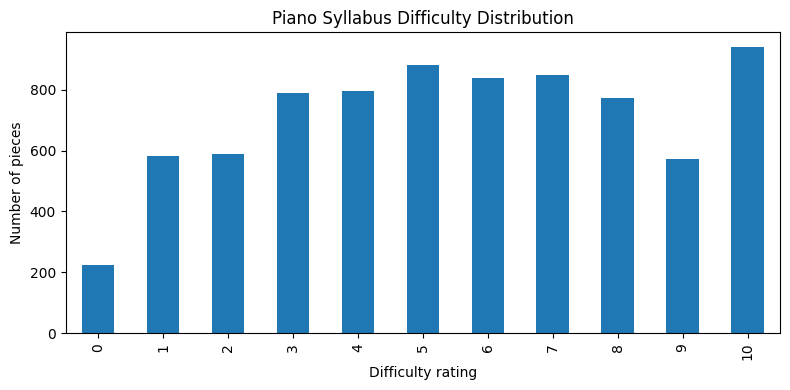

In [ ]:
# Load the cleaned Piano Syllabus dataset saved from the previous cleaning step.
df = pd.read_csv(PROCESSED_DIR / "pianosyllabus_clean.csv")

print("Clean rows:", len(df))
print("Difficulty levels:", sorted(df["difficulty"].unique()))

# Count how many pieces belong to each difficulty level.
difficulty_counts = df["difficulty"].value_counts().sort_index()

display(difficulty_counts)

plt.figure(figsize=(8, 4))
difficulty_counts.plot(kind="bar")
plt.xlabel("Difficulty rating")
plt.ylabel("Number of pieces")
plt.title("Piano Syllabus Difficulty Distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "difficulty_distribution_clean.png", dpi=200)
plt.show()

In [ ]:
%%run_if DO_DATAPROCESS

!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 101.4 MB/s eta 0:00:00


In [ ]:
%%run_if DO_DATAPROCESS

# This cell scrapes PianoLibrary.com, goes through every difficulty 10 piece
# in the JSON, does normalization/fuzzy matching and other checks to detect
# if there is a matching piece on PianoLibrary.

import json
import re
import html
import time
import unicodedata
import sys
import subprocess

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup

try:
    from rapidfuzz import fuzz, process
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "rapidfuzz"])
    from rapidfuzz import fuzz, process


PS_JSON_PATH = RAW_DIR / "new_clean_data.json"
OUTPUT_PATH = PROCESSED_DIR / "pianolibrary_matches.csv"

PL_PAGES = [
    ("1", 1.0), ("1-5", 1.5), ("2", 2.0), ("2-5", 2.5),
    ("3", 3.0), ("3-5", 3.5), ("4", 4.0), ("4-5", 4.5), ("5", 5.0),
]

PL_BASE_URL = "https://www.pianolibrary.org/difficulty/{slug}/"

MATCH_THRESHOLD = 95
TOP_K = 3
SEARCH_LIMIT = 150

CATALOG_PREFIXES = ["hobxvi", "mwvu", "woo", "bwv", "anh", "ct", "op", "s", "k", "l", "d"]

WORK_TYPES = {
    "sonata", "prelude", "etude", "ballade", "scherzo", "scherzino",
    "nocturne", "waltz", "mazurka", "impromptu", "toccata", "fantasy",
    "polonaise", "variation", "fugue", "suite", "concerto", "rhapsody",
    "catalogue", "regard", "march", "rondo", "polka", "allegro",
}

ROMAN = {
    "i": "1", "ii": "2", "iii": "3", "iv": "4",
    "v": "5", "vi": "6", "vii": "7", "viii": "8",
}


def simple_text(text):
    # Basic text cleaning
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch)).lower()
    text = text.replace("’", "'").replace("–", "-").replace("—", "-")
    text = re.sub(r"[^a-z0-9#]+", " ", text)
    return " ".join(text.split())


def composer_key(composer):
    # Match "Debussy C." with "Claude Debussy" using surname + first initial.
    tokens = simple_text(composer).split()
    particles = {"van", "von", "de", "da", "del", "der", "la", "le", "di"}

    if not tokens:
        return ""

    if len(tokens) >= 2 and len(tokens[0]) > 2 and len(tokens[1]) <= 2:
        return tokens[0] + "_" + tokens[1][0]

    tokens = [token for token in tokens if token not in particles]

    if not tokens:
        return ""

    return tokens[-1] + "_" + tokens[0][0]


def clean_title(text):
    # Normalize title spelling
    text = simple_text(text)

    replacements = [
        (r"\bhob\s*xvi\s*(\d+[a-z]*)", r"hobxvi \1"),
        (r"\bkv\s*(\d+[a-z]*)", r"k \1"),
        (r"\bmwv\s*u\s*(\d+[a-z]*)", r"mwvu \1"),
        (r"\bwoo\s*(\d+[a-z]*)", r"woo \1"),
        (r"\bopus\s*(\d+[a-z]*)", r"op \1"),
        (r"\bop\s*(\d+[a-z]*)", r"op \1"),
        (r"\bno\s*(\d+)([a-z]+)", r"no \1 \2"),
        (r"\bmvt\s*(\d+[a-z]?)", r"mvt \1"),
        (r"\bmovement\s*(\d+[a-z]?)", r"mvt \1"),
        (r"\bnumber\s*", r"no "),
    ]

    for old, new in replacements:
        text = re.sub(old, new, text)

    # Use same conventions for key signatures
    for old, new in {
        "db": "d flat", "eb": "e flat", "gb": "g flat", "ab": "a flat", "bb": "b flat",
        "f#": "f sharp", "c#": "c sharp", "g#": "g sharp", "d#": "d sharp", "a#": "a sharp",
    }.items():
        text = re.sub(rf"\b{re.escape(old)}\b", new, text)

    text = re.sub(r"\b(\d+)(st|nd|rd|th)\b", r"\1", text)

    for old, new in ROMAN.items():
        text = re.sub(rf"\b{old}\b", new, text)

    for prefix in CATALOG_PREFIXES:
        text = re.sub(rf"\b{prefix}\s*(\d+[a-z]*)", rf"{prefix} \1", text)

    # Replace synonyms
    synonyms = {
        "sonatas": "sonata", "etudes": "etude", "studies": "etude", "study": "etude",
        "preludes": "prelude", "nocturnes": "nocturne", "waltzes": "waltz",
        "mazurkas": "mazurka", "polonaises": "polonaise", "rhapsodies": "rhapsody",
        "rapsodies": "rhapsody", "rapsodie": "rhapsody", "fantasie": "fantasy",
        "variations": "variation", "catalogues": "catalogue", "regards": "regard",
        "klavierstucke": "piece", "klavierstuck": "piece",
    }

    # Remove stopwords
    stopwords = {
        "the", "a", "an", "and", "in", "from", "for", "de", "la", "le", "les",
        "des", "du", "sur", "by", "pour", "piano", "piece", "pieces", "work",
        "works", "movement", "version", "solo", "twenty", "four", "douze",
    }

    cleaned_tokens = []

    for token in text.split():
        token = synonyms.get(token, token)

        if token not in stopwords:
            cleaned_tokens.append(token)

    return " ".join(cleaned_tokens)


def catalog_prefix(catalog):
    # Used to detect conflicts only within the same catalogue system.
    for prefix in CATALOG_PREFIXES:
        if str(catalog).startswith(prefix):
            return prefix

    return ""


def catalog_values(prefix, value):
    # Expand catalogue forms, including Liszt compact forms like S24414.
    value = str(value).lower()
    catalogs = {prefix + value}
    nums = set()

    match = re.match(r"(\d+)([a-z]*)$", value)

    if not match:
        return catalogs, nums

    number = match.group(1)
    suffix = match.group(2)

    catalogs.add(prefix + number)

    # S216aL -> S216a
    if suffix.endswith("l") and len(suffix) > 1:
        catalogs.add(prefix + number + suffix[:-1])

    # S248ii -> S248 + movement 2
    if suffix in ROMAN:
        nums.add(ROMAN[suffix])

    # S24414 -> S244 + movement 14
    if prefix == "s" and suffix == "":
        if len(number) == 4:
            catalogs.add("s" + number[:3])
            nums.add(number[3:])
        elif len(number) == 5:
            catalogs.add("s" + number[:3])
            nums.add(number[3:])

    return catalogs, nums


def title_features(title, is_pl):
    # Extract the fields needed for matching and display.
    clean = clean_title(title)
    tokens = clean.split()

    work_type = next((token for token in tokens if token in WORK_TYPES), "")
    nums = set(re.findall(r"\b(?:no|mvt)\s+(\d+[a-z]?)\b", clean))
    catalogs = set()

    for prefix in CATALOG_PREFIXES:
        for value in re.findall(rf"\b{prefix}\s+(\d+[a-z]*)\b", clean):
            new_catalogs, new_nums = catalog_values(prefix, value)
            catalogs.update(new_catalogs)
            nums.update(new_nums)

    no_metadata = re.sub(
        r"\b(hobxvi|mwvu|woo|bwv|anh|ct|op|s|k|l|d|book|no|mvt)\s+\d+[a-z]*\b",
        " ",
        clean,
    )

    bare_tokens = no_metadata.split()

    for i, token in enumerate(bare_tokens):
        next_token = bare_tokens[i + 1] if i + 1 < len(bare_tokens) else ""

        if re.fullmatch(r"\d+[a-z]?", token):
            # PianoLibrary subpieces often have bare movement numbers like "3 Toccata".
            if is_pl and (i > 0 or next_token in WORK_TYPES):
                nums.add(token)

            # For PianoSyllabus, avoid treating collection counts like "24 Preludes" as movement numbers.
            elif not is_pl and i > 0 and next_token not in WORK_TYPES:
                nums.add(token)

    important = {
        token for token in tokens
        if token not in WORK_TYPES
        and token not in {"major", "minor", "flat", "sharp", "f", "c", "g", "a", "e", "b"}
        and not re.fullmatch(r"\d+[a-z]?", token)
        and token not in CATALOG_PREFIXES
        and token not in {"book", "no", "mvt"}
    }

    return pd.Series({
        "clean": clean,
        "work_type": work_type,
        "catalogs": catalogs,
        "nums": nums,
        "important": important,
    })


def catalog_conflict(a, b):
    # Reject only when both sides use the same catalogue system but disagree.
    for prefix in CATALOG_PREFIXES:
        left = {x for x in a if catalog_prefix(x) == prefix}
        right = {x for x in b if catalog_prefix(x) == prefix}

        if left and right and not (left & right):
            return True

    return False


def valid_match(ps, pl):
    # Hard rejection rules before scoring.
    same_catalog = bool(ps["ps_catalogs"] & pl["pl_catalogs"])
    same_num = bool(ps["ps_nums"] & pl["pl_nums"])
    same_work_type = bool(ps["ps_work_type"]) and ps["ps_work_type"] == pl["pl_work_type"]
    word_overlap = len(ps["ps_important"] & pl["pl_important"])

    if catalog_conflict(ps["ps_catalogs"], pl["pl_catalogs"]):
        return False

    if same_catalog and ps["ps_nums"] and pl["pl_nums"] and not same_num and word_overlap == 0:
        return False

    if ps["ps_nums"] and pl["pl_nums"] and not same_num and (same_work_type or word_overlap > 0):
        return False

    if ps["ps_work_type"] and pl["pl_work_type"] and ps["ps_work_type"] != pl["pl_work_type"]:
        if not same_catalog and word_overlap == 0:
            return False

    return True


def match_score(rough, ps, pl):
    # Calculate a score based on the fuzzy match score plus any
    # matching factors.
    if not valid_match(ps, pl):
        return -1

    same_catalog = bool(ps["ps_catalogs"] & pl["pl_catalogs"])
    same_num = bool(ps["ps_nums"] & pl["pl_nums"])
    same_work_type = bool(ps["ps_work_type"]) and ps["ps_work_type"] == pl["pl_work_type"]
    word_overlap = len(ps["ps_important"] & pl["pl_important"])
    number_has_context = same_num and (same_catalog or same_work_type or word_overlap > 0)

    return (
        float(rough)
        + 80 * same_catalog
        + 35 * number_has_context
        + 10 * same_work_type
        + 35 * word_overlap
    )


# Scrape PianoLibrary rows.
rows = []

for slug, rating in PL_PAGES:
    url = PL_BASE_URL.format(slug=slug)
    print("Scraping:", url)

    response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    composer = ""

    for tag in soup.find_all(["h3", "ul"]):
        if tag.name == "h3" and "section_title" in tag.get("class", []):
            link = tag.find("a")
            composer = link.get_text(" ", strip=True) if link else tag.get_text(" ", strip=True)

        elif tag.name == "ul" and "list" in tag.get("class", []):
            parent_title = ""

            for li in tag.find_all("li", recursive=False):
                parent_link = li.find("a", recursive=False)
                sublist = li.find("ul", class_="sublist", recursive=False)

                if parent_link is not None:
                    parent_title = parent_link.get_text(" ", strip=True)

                    rows.append({
                        "pl_composer": composer,
                        "pl_match_title": parent_title,
                        "pl_rating": rating,
                        "is_subpiece": False,
                    })

                if sublist is not None:
                    for sub_li in sublist.find_all("li", recursive=False):
                        sub_link = sub_li.find("a")

                        if sub_link is not None:
                            sub_title = sub_link.get_text(" ", strip=True)

                            rows.append({
                                "pl_composer": composer,
                                "pl_match_title": parent_title + " " + sub_title,
                                "pl_rating": rating,
                                "is_subpiece": True,
                            })

    time.sleep(0.3)


# Build PianoLibrary match table.
pl_df = pd.DataFrame(rows)
pl_df["composer_key"] = pl_df["pl_composer"].apply(composer_key)

pl_features = pl_df["pl_match_title"].apply(lambda x: title_features(x, is_pl=True)).add_prefix("pl_")
pl_df = pd.concat([pl_df.reset_index(drop=True), pl_features.reset_index(drop=True)], axis=1)


# Load PianoSyllabus rows.
with open(PS_JSON_PATH, "r", encoding="utf-8") as f:
    ps_data = json.load(f)

ps_df = pd.DataFrame([
    {
        "ps_key": key,
        "ps_composer": item.get("composer", ""),
        "ps_title": item.get("PS_title", ""),
        "ps_rating": float(item.get("ps_rating", item.get("ps", np.nan))),
    }
    for key, item in ps_data.items()
])

ps_df["composer_key"] = ps_df["ps_composer"].apply(composer_key)

ps_features = ps_df["ps_title"].apply(lambda x: title_features(x, is_pl=False)).add_prefix("ps_")
ps_df = pd.concat([ps_df.reset_index(drop=True), ps_features.reset_index(drop=True)], axis=1)


# Match only PianoSyllabus grade-10 rows.
pl_by_composer = {name: group.copy() for name, group in pl_df.groupby("composer_key")}
match_rows = []

for i, (_, ps) in enumerate(ps_df[ps_df["ps_rating"] == 10].iterrows(), start=1):
    if i % 50 == 0:
        print("Matching", i)

    candidates = pl_by_composer.get(ps["composer_key"])

    if candidates is None or len(candidates) == 0:
        row = {
            "ps_key": ps["ps_key"],
            "ps_composer": ps["ps_composer"],
            "ps_title": ps["ps_title"],
            "match_status": "no_same_composer",
            "match_score": 0,
            "rough_score": 0,
            "pl_match_title": "",
            "pl_rating": np.nan,
        }

        for k in range(1, TOP_K + 1):
            row[f"top{k}_score"] = np.nan
            row[f"top{k}_rating"] = np.nan
            row[f"top{k}_title"] = ""

        match_rows.append(row)
        continue

    choices = dict(zip(candidates.index, candidates["pl_clean"]))

    rough_scores = {
        idx: rough
        for _, rough, idx in process.extract(
            ps["ps_clean"],
            choices,
            scorer=fuzz.WRatio,
            limit=SEARCH_LIMIT,
        )
    }

    # Add candidates that fuzzy search might miss but metadata suggests are relevant.
    for idx, pl in candidates.iterrows():
        has_metadata_overlap = (
            ps["ps_catalogs"] & pl["pl_catalogs"]
            or ps["ps_important"] & pl["pl_important"]
            or (ps["ps_work_type"] and ps["ps_work_type"] == pl["pl_work_type"])
        )

        if has_metadata_overlap:
            rough_scores.setdefault(idx, fuzz.WRatio(ps["ps_clean"], pl["pl_clean"]))

    scored = []

    for idx, rough in rough_scores.items():
        pl = candidates.loc[idx]
        scored.append((match_score(rough, ps, pl), rough, idx))

    scored = sorted(scored, reverse=True)[:TOP_K]

    best_score, best_rough, best_idx = scored[0]
    best = candidates.loc[best_idx]

    same_work_type = bool(ps["ps_work_type"]) and ps["ps_work_type"] == best["pl_work_type"]
    same_num = bool(ps["ps_nums"] & best["pl_nums"])
    word_overlap = len(ps["ps_important"] & best["pl_important"])

    # Same number alone is not evidence. It must have title/catalog/work-type support.
    enough_evidence = (
        bool(ps["ps_catalogs"] & best["pl_catalogs"])
        or word_overlap > 0
        or (same_work_type and same_num)
        or (same_work_type and ps["ps_work_type"] != "prelude" and best_rough >= 85)
    )

    row = {
        "ps_key": ps["ps_key"],
        "ps_composer": ps["ps_composer"],
        "ps_title": ps["ps_title"],
        "match_status": "matched" if best_score >= MATCH_THRESHOLD and enough_evidence else "no_match",
        "match_score": best_score,
        "rough_score": best_rough,
        "pl_match_title": best["pl_match_title"],
        "pl_rating": best["pl_rating"],
    }

    for k in range(TOP_K):
        if k < len(scored):
            score, rough, idx = scored[k]
            top = candidates.loc[idx]

            row[f"top{k+1}_score"] = score
            row[f"top{k+1}_rating"] = top["pl_rating"]
            row[f"top{k+1}_title"] = top["pl_match_title"]
        else:
            row[f"top{k+1}_score"] = np.nan
            row[f"top{k+1}_rating"] = np.nan
            row[f"top{k+1}_title"] = ""

    match_rows.append(row)


# Save and display the match results.
matches_df = pd.DataFrame(match_rows)
matches_df.to_csv(OUTPUT_PATH, index=False)

matched_df = matches_df[matches_df["match_status"] == "matched"]
unmatched_df = matches_df[matches_df["match_status"] != "matched"]

print("Saved:", OUTPUT_PATH)
print("Matched:", len(matched_df))
print("No match:", (matches_df["match_status"] == "no_match").sum())
print("No same composer:", (matches_df["match_status"] == "no_same_composer").sum())

print()
print("Matched rating distribution:")
print(matched_df["pl_rating"].value_counts().sort_index())

print()
print("Matched:")
display(
    matched_df[["ps_composer", "ps_title", "pl_match_title", "pl_rating", "match_score", "rough_score"]]
    .sort_values(["pl_rating", "match_score"], ascending=[False, False])
    .head(150)
)

print()
print("Unmatched / needs review:")
display(
    unmatched_df[[
        "ps_composer",
        "ps_title",
        "match_status",
        "match_score",
        "rough_score",
        "pl_rating",
        "pl_match_title",
        "top1_score",
        "top1_rating",
        "top1_title",
        "top2_score",
        "top2_rating",
        "top2_title",
        "top3_score",
        "top3_rating",
        "top3_title",
    ]]
    .sort_values("match_score", ascending=False)
    .head(150)
)

Scraping: https://www.pianolibrary.org/difficulty/1/
Scraping: https://www.pianolibrary.org/difficulty/1-5/
Scraping: https://www.pianolibrary.org/difficulty/2/
Scraping: https://www.pianolibrary.org/difficulty/2-5/
Scraping: https://www.pianolibrary.org/difficulty/3/
Scraping: https://www.pianolibrary.org/difficulty/3-5/
Scraping: https://www.pianolibrary.org/difficulty/4/
Scraping: https://www.pianolibrary.org/difficulty/4-5/
Scraping: https://www.pianolibrary.org/difficulty/5/
Matching 50
Matching 100
Matching 150
Matching 200
Matching 250
Matching 300
Matching 350
Matching 400
Matching 450
Matching 500
Matching 550
Matching 600
Matching 650
Matching 700
Matching 750
Matching 800
Matching 850
Matching 900
Matching 950
Saved: /content/drive/MyDrive/APS360_Piano_Difficulty/data/processed/pianolibrary_matches.csv
Matched: 466
No match: 49
No same composer: 436

Matched rating distribution:
pl_rating
2.0      3
2.5     10
3.0     33
3.5     93
4.0     94
4.5    131
5.0    102
Name: coun

,ps_composer,ps_title,pl_match_title,pl_rating,match_score,rough_score
751,Liszt F.,Apres une Lecture de Dante No 7 from Annees de...,"Années de pèlerinage, Deuxième année (Italie),...",5.0,484.242424,89.242424
643,Szymanowski K.,Variations on a Polish Folk Theme Op 10,"Variations on a Polish Folk Theme, op. 10",5.0,330.000000,100.000000
63,Liszt F.,Grandes etudes de Paganini - La Campanella (th...,"Six Grandes études de Paganini, S. 141 3. G-sh...",5.0,317.830189,87.830189
720,Brahms J.,Variations and Fugue on a Theme by Handel in B...,"Variations and Fugue on a Theme by Handel, op. 24",5.0,290.000000,95.000000
432,Liszt F.,Grandes Etudes de Paganini S141 No 6,"Six Grandes études de Paganini, S. 141 6. A minor",5.0,285.476190,90.476190
...,...,...,...,...,...,...
55,Shostakovich D.,Prelude and Fugue in G minor Op 87 No 12,"Twenty-four Preludes and Fugues, op. 87 12. G-...",4.5,215.476190,90.476190
93,Chopin F.,Fantaisie in F minor Op 49,"Fantaisie in F minor, op. 49",4.5,215.000000,100.000000
363,Chopin F.,Etude in Eb major Op 10 No 11,"Twelve Études, op. 10 11. E-flat major",4.5,215.000000,90.000000
681,Schumann R.,Kreisleriana - op 16,"Kreisleriana, op. 16",4.5,215.000000,100.000000



Unmatched / needs review:


,ps_composer,ps_title,match_status,match_score,rough_score,pl_rating,pl_match_title,top1_score,top1_rating,top1_title,top2_score,top2_rating,top2_title,top3_score,top3_rating,top3_title
347,Schubert F.,Marche Militaire D 733 No 1 arr. Tausig,no_match,85.5,85.5,2.0,"Minuet in D major, D Anh. I, 15",85.5,2.0,"Minuet in D major, D Anh. I, 15",85.5,1.5,"Allegro and Minuet, D Anh. I, 11",-1.0,2.5,"Sonata in B-flat major, D 960 3. Scherzo: Alle..."
770,Debussy C.,Pour le piano (complete) L95,no_match,85.5,85.5,4.5,"Images, Série 1 1. Reflets dans l’eau",85.5,4.5,"Images, Série 1 1. Reflets dans l’eau",85.5,3.5,"Préludes, Livre 1 4. Les sons et les parfums t...",85.5,3.0,Six Épigraphes antiques 5. Pour l’Egyptienne
120,Schubert F.,Gretchen am spinnrade - solo piano version - o...,no_match,85.5,85.5,2.0,"Minuet in D major, D Anh. I, 15",85.5,2.0,"Minuet in D major, D Anh. I, 15",85.5,1.5,"Allegro and Minuet, D Anh. I, 11",-1.0,2.5,"Sonata in B major, D 575"
600,Bach J.S.,Chaconne in D minor arr. Brahms (transcribed f...,no_match,85.5,85.5,3.5,"Toccata in F minor, BWV Anh. 85 (version B)",85.5,3.5,"Toccata in F minor, BWV Anh. 85 (version B)",85.5,3.5,"Toccata in F minor, BWV Anh. 85 (version A)",85.5,3.5,"Toccata in F minor, BWV Anh. 85"
544,Bach J.S.,Chaconne in D minor arr. Busoni,no_match,85.5,85.5,2.5,"Concerto and Fugue in C minor, BWV 909 1. Conc...",85.5,2.5,"Concerto and Fugue in C minor, BWV 909 1. Conc...",85.5,2.5,Concerto in D minor after Johann Ernst of Saxe...,85.5,2.5,Concerto in D minor after Johann Ernst of Saxe...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,Loschhorn A.,Etude in E minor No 5 from Etuden fur Geubtere...,no_same_composer,0.0,0.0,NaN,,NaN,NaN,,NaN,NaN,,NaN,NaN,
68,Rzewski F.,Which Side Are You On No 2 from North American...,no_same_composer,0.0,0.0,NaN,,NaN,NaN,,NaN,NaN,,NaN,NaN,
67,Lyapunov S.,Etude Op 1 No 1,no_same_composer,0.0,0.0,NaN,,NaN,NaN,,NaN,NaN,,NaN,NaN,
66,Garant S.,Cage doiseau,no_same_composer,0.0,0.0,NaN,,NaN,NaN,,NaN,NaN,,NaN,NaN,


In [ ]:
%%run_if DO_DATAPROCESS

# The matches above were verified manually and using ChatGPT
# Manual changes are done below


MATCH_PATH = PROCESSED_DIR / "pianolibrary_matches.csv"
matches_df = pd.read_csv(MATCH_PATH)

fix = {
    "Bach J.S.English suite in A major BWV 806 - Gigue 8th mvt":
        ("English Suite no. 1 in A major, BWV 806 7. Gigue", 4.0),
    "Mendelssohn F.Scherzo in B minor WoO2":
        ("Scherzo in B minor, MWV U 69", 3.5),
}

remove = [
    "Mendelssohn F.Scherzo from A Midsummer Nights Dream arr. Rachmaninoff",
    "Mendelssohn F.Capriccio Brillant Op 22",
]

for k, v in fix.items():
    matches_df.loc[matches_df["ps_key"] == k, ["match_status", "pl_match_title", "pl_rating"]] = ["matched", v[0], v[1]]

for k in remove:
    matches_df.loc[matches_df["ps_key"] == k, ["match_status", "pl_match_title", "pl_rating"]] = ["no_match", "", np.nan]

matches_df.to_csv(MATCH_PATH, index=False)

In [ ]:
%%run_if DO_DATAPROCESS

# Update difficulty label of dataset for matched pieces
# 1.0-3.5 = remains at difficulty 10
# 4.0-5.0 = difficulty 11

df = pd.read_csv(PROCESSED_DIR / "pianosyllabus_clean.csv")

label_map = {}

for _, row in matches_df.iterrows():
    if row["match_status"] != "matched":
        continue

    rating = row["pl_rating"]

    if pd.isna(rating):
        continue

    if rating <= 3.5:
        new_label = 10
    else:
        new_label = 11

    label_map[row["ps_key"]] = new_label

for i in df.index:
    title = df.loc[i, "title"]

    if title in label_map:
        df.loc[i, "difficulty"] = label_map[title]

df.to_csv(PROCESSED_DIR / "pianosyllabus_clean.csv", index=False)

In [ ]:
# Check for any errors in the dataset by printing statistics

df = pd.read_csv(PROCESSED_DIR / "pianosyllabus_clean.csv")

print("Rows:", len(df))
print("Unique titles:", df["title"].nunique())
print("Unique composers:", df["composer"].nunique())
print("Difficulty values:", sorted(df["difficulty"].unique()))

print("\nMissing values:")
display(df[["title", "composer", "difficulty", "midi_filename", "local_midi_path"]].isna().sum())

print("\nInvalid difficulty rows:")
display(df[(df["difficulty"] < 0) | (df["difficulty"] > 11)])

print("\nExact duplicate composer-title rows:")
duplicates = df[df.duplicated(["composer", "title"], keep=False)]
display(duplicates.sort_values(["composer", "title"])[[
    "composer",
    "title",
    "difficulty",
    "midi_filename",
]])

Rows: 7833
Unique titles: 7833
Unique composers: 1233
Difficulty values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

Missing values:


,0
title,0
composer,0
difficulty,0
midi_filename,0
local_midi_path,0



Invalid difficulty rows:


,title,composer,difficulty,YT_chapters,start,end,midi_filename,midi_path,local_midi_path



Exact duplicate composer-title rows:


,composer,title,difficulty,midi_filename


,count
difficulty,
0,224
1,581
2,588
3,789
4,795
5,881
6,839
7,849
8,772


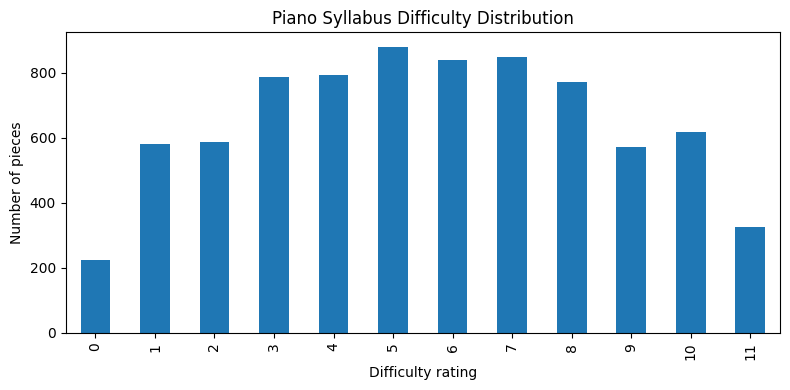

In [ ]:
difficulty_counts = df["difficulty"].value_counts().sort_index()

display(difficulty_counts)

plt.figure(figsize=(8, 4))
difficulty_counts.plot(kind="bar")
plt.xlabel("Difficulty rating")
plt.ylabel("Number of pieces")
plt.title("Piano Syllabus Difficulty Distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "difficulty_distribution_clean.png", dpi=200)
plt.show()

In [ ]:
# Show one cleaned data example

clean_df = pd.read_csv(PROCESSED_DIR / "pianosyllabus_clean.csv")

sample = clean_df.sample(1, random_state=432)

cols = [
    "title",
    "composer",
    "difficulty",
    "duration",
    "local_midi_path",
]

cols = [col for col in cols if col in sample.columns]

display(sample[cols].T.rename(columns={sample.index[0]: "cleaned sample"}))

,cleaned sample
title,Bor M.Fuga No. 1
composer,Bor M.
difficulty,7
local_midi_path,/content/aps360_local_mid/Bor M.Fuga No. 1.mid


In [ ]:
# Split into train, val, and test datasets

df = pd.read_csv(PROCESSED_DIR / "pianosyllabus_clean.csv")

# Split based on composers instead of individual pieces so the same composer never appears in multiple splits.
rng = np.random.default_rng(359)
composers = df["composer"].dropna().unique().tolist()
rng.shuffle(composers)

total_rows = len(df)
train_target = 0.70 * total_rows
val_target = 0.15 * total_rows

train_composers = set()
val_composers = set()
test_composers = set()

train_rows = 0
val_rows = 0

# Add composers until the target data count is passed (will slightly overshoot)
for composer in composers:
    added_rows = (df["composer"] == composer).sum()

    if train_rows < train_target:
        train_composers.add(composer)
        train_rows += added_rows

    elif val_rows < val_target:
        val_composers.add(composer)
        val_rows += added_rows

    else:
        test_composers.add(composer)

train_df = df[df["composer"].isin(train_composers)].copy()
val_df = df[df["composer"].isin(val_composers)].copy()
test_df = df[df["composer"].isin(test_composers)].copy()

train_df.to_csv(PROCESSED_DIR / "train.csv", index=False)
val_df.to_csv(PROCESSED_DIR / "val.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test.csv", index=False)

print("Train rows:", len(train_df), " | Composers:", train_df["composer"].nunique())
print("Validation rows:", len(val_df), "| Composers:", val_df["composer"].nunique())
print("Test rows:", len(test_df), " | Composers:", test_df["composer"].nunique())

# Print how many of each difficulty are in train, val, and test
split_counts = pd.DataFrame({
    "train": train_df["difficulty"].value_counts().sort_index(),
    "val": val_df["difficulty"].value_counts().sort_index(),
    "test": test_df["difficulty"].value_counts().sort_index(),
}).fillna(0).astype(int)

display(split_counts)

print("Saved:", PROCESSED_DIR / "train.csv")
print("Saved:", PROCESSED_DIR / "val.csv")
print("Saved:", PROCESSED_DIR / "test.csv")

Train rows: 5488  | Composers: 855
Validation rows: 1175 | Composers: 199
Test rows: 1170  | Composers: 179


,train,val,test
difficulty,,,
0,165,34,25
1,413,80,88
2,414,82,92
3,583,103,103
4,590,103,102
5,651,122,108
6,584,127,128
7,591,129,129
8,533,127,112


Saved: /content/drive/MyDrive/APS360_Piano_Difficulty/data/processed/train.csv
Saved: /content/drive/MyDrive/APS360_Piano_Difficulty/data/processed/val.csv
Saved: /content/drive/MyDrive/APS360_Piano_Difficulty/data/processed/test.csv


In [ ]:
%%run_if DO_BASELINE

# Extract basic features from pieces for baseline model

import pretty_midi
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

def extract_features(midi_path):
    # Read the MIDI file
    midi = pretty_midi.PrettyMIDI(str(midi_path))

    # Collect all non-drum notes from all instruments
    notes = []
    for instrument in midi.instruments:
        if not instrument.is_drum:
            notes.extend(instrument.notes)

    if len(notes) == 0:
        return None

    pitches = np.array([note.pitch for note in notes])
    starts = np.array([note.start for note in notes])
    ends = np.array([note.end for note in notes])
    durations = ends - starts

    midi_duration = midi.get_end_time()

    # Sort notes by start tims
    order = np.argsort(starts)
    ordered_pitches = pitches[order]

    # Calculate all jumps
    if len(ordered_pitches) > 1:
        pitch_jumps = np.abs(np.diff(ordered_pitches))
    else:
        pitch_jumps = np.array([0])

    # Record tempo changes if it's included in the MIDI metadata
    tempo_times, tempo = midi.get_tempo_changes()

    if len(tempo) > 0:
        mean_tempo = float(np.mean(tempo))
    else:
        mean_tempo = np.nan

    return {
        "midi_duration": midi_duration,
        "num_notes": len(notes),
        "notes_per_second": len(notes) / midi_duration if midi_duration > 0 else 0,
        "pitch_range": pitches.max() - pitches.min(),
        "mean_note_duration": durations.mean(),
        "std_note_duration": durations.std(),
        "mean_pitch_jump": pitch_jumps.mean(),
        "max_pitch_jump": pitch_jumps.max(),
        "mean_tempo": mean_tempo,
    }


# Build DF containing features
def build_feature_table(csv_path):
    split_df = pd.read_csv(csv_path)

    rows = []

    for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
        try:
            features = extract_features(row["local_midi_path"])

            if features is None:
                continue

            features["title"] = row["title"]
            features["composer"] = row["composer"]
            features["difficulty"] = row["difficulty"]
            features["midi_filename"] = row["midi_filename"]

            rows.append(features)

        except Exception as e:
            print("Skipped:", row["title"], "|", e)

    return pd.DataFrame(rows)


print("Building train feature table")
train_features = build_feature_table(PROCESSED_DIR / "train.csv")
print("Building val feature table")
val_features = build_feature_table(PROCESSED_DIR / "val.csv")
print("Building test feature table")
test_features = build_feature_table(PROCESSED_DIR / "test.csv")

train_features.to_csv(PROCESSED_DIR / "train_features.csv", index=False)
val_features.to_csv(PROCESSED_DIR / "val_features.csv", index=False)
test_features.to_csv(PROCESSED_DIR / "test_features.csv", index=False)

print("Train features:", train_features.shape)
print("Val features:", val_features.shape)
print("Test features:", test_features.shape)

display(train_features)


Building train feature table


100%|██████████| 5488/5488 [02:33<00:00, 35.79it/s]


Building val feature table


100%|██████████| 1175/1175 [00:34<00:00, 34.44it/s]


Building test feature table


100%|██████████| 1170/1170 [00:39<00:00, 29.63it/s]


Train features: (5488, 13)
Val features: (1175, 13)
Test features: (1170, 13)


,midi_duration,num_notes,notes_per_second,pitch_range,mean_note_duration,std_note_duration,mean_pitch_jump,max_pitch_jump,mean_tempo,title,composer,difficulty,midi_filename
0,91.044271,1133,12.444495,80,0.277384,0.648407,5.298587,67,120.00000,Dichler J.Toccata-Etude,Dichler J.,7,Dichler J.Toccata-Etude.mid
1,127.589844,612,4.796620,39,0.678171,0.678086,10.831424,33,120.00000,Farnaby G.Tell Me Daphne,Farnaby G.,7,Farnaby G.Tell Me Daphne.mid
2,108.619792,486,4.474323,69,1.051092,0.702888,10.882474,60,120.00000,Bonis M.Prelude,Bonis M.,7,Bonis M.Prelude.mid
3,44.156250,641,14.516631,57,0.292843,0.366268,11.823438,36,120.00000,Czerny C.Study - op 299 no 27 Bb major,Czerny C.,7,Czerny C.Study - op 299 no 27 Bb major.mid
4,78.609375,639,8.128801,65,0.201238,0.182903,16.250784,48,120.00000,Gregson E.Adams Allemande,Gregson E.,7,Gregson E.Adams Allemande.mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5483,108.787760,429,3.943458,53,1.726742,1.461186,15.913551,43,120.00000,Arens B.Daydream,Arens B.,5,Arens B.Daydream.mid
5484,148.679688,1006,6.766224,59,0.774592,0.876631,11.400000,52,120.00000,Arens B.Circle of Stones,Arens B.,5,Arens B.Circle of Stones.mid
5485,58.878906,378,6.419956,43,0.162809,0.254072,11.893899,33,120.00000,Scarlatti D.Sonata in C major K 73b,Scarlatti D.,2,Scarlatti D.Sonata in C major K 73b.mid
5486,550.119601,2183,3.968228,74,0.791367,1.124206,7.949588,49,191.58495,Rochberg G.Nach Bach,Rochberg G.,10,Rochberg G.Nach Bach.mid


In [ ]:
%%run_if DO_BASELINE

# BASELINE MODEL

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

train_features = pd.read_csv(PROCESSED_DIR / "train_features.csv")
val_features = pd.read_csv(PROCESSED_DIR / "val_features.csv")
test_features = pd.read_csv(PROCESSED_DIR / "test_features.csv")

feature_cols = [
    "midi_duration",
    "num_notes",
    "notes_per_second",
    "pitch_range",
    "mean_note_duration",
    "std_note_duration",
    "mean_pitch_jump",
    "max_pitch_jump",
    "mean_tempo",
]

# Fill missing feature values using only the training set.
X_train = train_features[feature_cols]
y_train = train_features["difficulty"]

X_val = val_features[feature_cols]
y_val = val_features["difficulty"]

# Random forest can learn nonlinear relationships between MIDI features.
baseline = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=3,
    max_depth=None,
    max_features = 1.0,
    n_jobs=-1,
    random_state=42,
)

baseline.fit(X_train, y_train)

train_pred = baseline.predict(X_train)
val_pred = baseline.predict(X_val)

def print_scores(name, y_true, y_pred):
    y_pred = np.clip(y_pred, 0, 11)
    rounded_pred = np.rint(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    exact_accuracy = np.mean(rounded_pred == y_true)
    within_1_accuracy = np.mean(np.abs(y_true - rounded_pred) <= 1)

    print(name)
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("Exact rounded accuracy:", round(exact_accuracy, 3))
    print("Within 1 difficulty level:", round(within_1_accuracy, 3))
    print()

print_scores("Train", y_train, train_pred)
print_scores("Validation", y_val, val_pred)


Train
MAE: 0.619
RMSE: 0.848
Exact rounded accuracy: 0.532
Within 1 difficulty level: 0.919

Validation
MAE: 1.241
RMSE: 1.602
Exact rounded accuracy: 0.289
Within 1 difficulty level: 0.657



In [ ]:
%%run_if DO_BASELINE

X_test = test_features[feature_cols]
y_test = test_features["difficulty"]

test_pred = baseline.predict(X_test)
print_scores("Test", y_test, test_pred)

Test
MAE: 1.161
RMSE: 1.523
Exact rounded accuracy: 0.287
Within 1 difficulty level: 0.719



In [ ]:
%%run_if DO_BASELINE

# Show songs with the largest prediction errors to analyze qualitatively

def show_largest_errors(split_name, features_df, y_true, y_pred, n=15):
    error_df = features_df[[
        "composer",
        "title",
        "difficulty",
        "midi_filename",
        "midi_duration",
        "num_notes",
        "notes_per_second",
        "pitch_range",
        "mean_note_duration",
        "std_note_duration",
        "mean_pitch_jump",
        "max_pitch_jump",
        "mean_tempo",
    ]].copy()

    error_df["predicted_difficulty"] = y_pred
    error_df["rounded_prediction"] = np.rint(y_pred)
    error_df["error"] = error_df["predicted_difficulty"] - error_df["difficulty"]
    error_df["absolute_error"] = error_df["error"].abs()

    print(split_name, "largest errors:")
    display(
        error_df.sort_values("absolute_error", ascending=False)
        .head(n)
        [[
            "composer",
            "title",
            "difficulty",
            "predicted_difficulty",
            "rounded_prediction",
            "error",
            "absolute_error",
            "midi_filename",
            "midi_duration",
            "num_notes",
            "notes_per_second",
            "pitch_range",
            "mean_note_duration",
            "std_note_duration",
            "mean_pitch_jump",
            "max_pitch_jump",
            "mean_tempo",
        ]]
    )

show_largest_errors("Validation", val_features, y_val, val_pred)
show_largest_errors("Test", test_features, y_test, test_pred)

Validation largest errors:


,composer,title,difficulty,predicted_difficulty,rounded_prediction,error,absolute_error,midi_filename,midi_duration,num_notes,notes_per_second,pitch_range,mean_note_duration,std_note_duration,mean_pitch_jump,max_pitch_jump,mean_tempo
863,Bach J.S.,Bach J.S.English suite in A major BWV 806 - Gi...,11,4.494208,4.0,-6.505792,6.505792,Bach J.S.English suite in A major BWV 806 - Gi...,82.098250,962,11.717668,50,0.140984,0.316095,15.982310,43,200.922233
1009,Bach J.S.,Bach J.S.French Suite no 5 in G major BWV 816,10,4.148881,4.0,-5.851119,5.851119,Bach J.S.French Suite no 5 in G major BWV 816.mid,84.069328,611,7.267811,46,0.378235,0.399276,12.157377,40,231.208527
856,Bach J.S.,Bach J.S.Goldberg Variations - Aria and variat...,9,3.822957,4.0,-5.177043,5.177043,Bach J.S.Goldberg Variations - Aria and variat...,63.158920,402,6.364897,46,0.494372,0.339836,12.822943,41,234.974368
958,Bach J.S.,Bach J.S.Goldberg Variations - Aria and variat...,9,3.973268,4.0,-5.026732,5.026732,Bach J.S.Goldberg Variations - Aria and variat...,61.056963,450,7.370167,43,0.327602,0.270620,12.440980,38,198.163683
892,Bach J.S.,Bach J.S.Minuet in G major BWV 114,1,5.984761,6.0,4.984761,4.984761,Bach J.S.Minuet in G major BWV 114.mid,108.899390,885,8.126767,60,0.334465,0.340865,9.555430,56,174.779341
1005,Schumann R.,Schumann R.Davidsbundlertanze - op 6,11,6.026523,6.0,-4.973477,4.973477,Schumann R.Davidsbundlertanze - op 6.mid,90.000311,711,7.899973,55,0.605190,0.468478,11.445070,43,200.638700
212,Biehl A.,Biehl A.Sonatina in C major,1,5.946194,6.0,4.946194,4.946194,Biehl A.Sonatina in C major.mid,137.723958,1070,7.769164,60,0.259150,0.329088,14.168382,53,120.000000
1002,Schumann R.,Schumann R.Album Leaves V - op 99 no 8 Eb major,9,4.074494,4.0,-4.925506,4.925506,Schumann R.Album Leaves V - op 99 no 8 Eb majo...,97.194400,342,3.518721,50,1.250089,1.062244,10.225806,31,141.554170
873,Bach J.S.,Bach J.S.Fugue No 6 in D minor from WTC Book 2...,10,5.128923,5.0,-4.871077,4.871077,Bach J.S.Fugue No 6 in D minor from WTC Book 2...,118.679039,848,7.145322,45,0.399530,0.345670,10.325856,40,218.992489
539,Schumann R.,Schumann R.Caprice - op 3 no 3 C major,10,5.130717,5.0,-4.869283,4.869283,Schumann R.Caprice - op 3 no 3 C major.mid,145.544271,550,3.778919,51,1.170080,0.826436,8.526412,33,120.000000


Test largest errors:


,composer,title,difficulty,predicted_difficulty,rounded_prediction,error,absolute_error,midi_filename,midi_duration,num_notes,notes_per_second,pitch_range,mean_note_duration,std_note_duration,mean_pitch_jump,max_pitch_jump,mean_tempo
93,Chopin F.,Chopin F.Prelude in C minor Op 28 no 10,9,3.094516,3.0,-5.905484,5.905484,Chopin F.Prelude in C minor Op 28 no 10.mid,29.485677,304,10.310091,65,0.398236,0.443023,13.600660,55,120.0
75,Chopin F.,Chopin F.Prelude in D major Op 28 No 5,9,3.226963,3.0,-5.773037,5.773037,Chopin F.Prelude in D major Op 28 No 5.mid,32.628906,460,14.097929,52,0.240871,0.299996,13.736383,52,120.0
62,Chopin F.,Chopin F.Prelude in B major Op 28 no 11,9,3.268603,3.0,-5.731397,5.731397,Chopin F.Prelude in B major Op 28 no 11.mid,46.069010,322,6.989514,53,0.798157,0.927312,12.669782,40,120.0
137,Stockhausen K.,Stockhausen K.Klavierstucke VIII,10,4.560176,5.0,-5.439824,5.439824,Stockhausen K.Klavierstucke VIII.mid,121.625000,435,3.576567,82,0.643445,0.908223,19.603687,79,120.0
522,Diabelli A.,Diabelli A.Moderato Op 125 No 1,0,5.412719,5.0,5.412719,5.412719,Diabelli A.Moderato Op 125 No 1.mid,302.500000,529,1.748760,38,1.071691,0.742922,7.653409,33,120.0
710,Matthews M.,Matthews M.Timelessness,4,9.386137,9.0,5.386137,5.386137,Matthews M.Timelessness.mid,235.829427,1807,7.662318,71,1.374075,1.441239,11.884828,57,120.0
770,Chopin F.,Chopin F.Prelude in Bb minor Op 28 No 16,11,5.619285,6.0,-5.380715,5.380715,Chopin F.Prelude in Bb minor Op 28 No 16.mid,61.145833,1209,19.772402,74,0.179583,0.181444,15.651490,68,120.0
133,Chopin F.,Chopin F.Mazurka in C minor Op 30 No 1 CT 68,10,4.673336,5.0,-5.326664,5.326664,Chopin F.Mazurka in C minor Op 30 No 1 CT 68.mid,97.158854,578,5.949020,49,0.652139,0.644693,8.469671,44,120.0
357,Chatman S.,Chatman S.Sneaky,8,2.930836,3.0,-5.069164,5.069164,Chatman S.Sneaky.mid,97.343750,401,4.119422,56,0.372477,0.494678,12.722500,45,120.0
391,Daquin L.,Daquin L.Gavotte en Rondeau Les Plaisirs de la...,2,7.002508,7.0,5.002508,5.002508,Daquin L.Gavotte en Rondeau Les Plaisirs de la...,406.839844,3912,9.615577,69,0.166219,0.235222,11.681923,46,120.0


In [ ]:
import torch
from tqdm import tqdm
import pretty_midi
from collections import defaultdict

"""
Turn midi file into the following structure:
piece = [
    segment1,
    segment2,
    ...
]

where:

segment = [
  [pitch, onset, duration, velocity, delta onset],
  [pitch, onset, duration, velocity, delta onset],
  ...
]
"""

SEGMENT_SECONDS = 5.0
NOTE_FEATURES = 5   # pitch, onset within segment, duration, velocity, delta onset

SEQUENCE_DIR = PROCESSED_DIR / "sequence_arrays"
SEQUENCE_DIR.mkdir(parents=True, exist_ok=True)

QUANTIZE_DIVISIONS_PER_BEAT = 32

def interp_with_extrapolation(x, xp, fp):
    # Interpolation function that also supports extrapolation for the start/end beats
    x = np.asarray(x, dtype=np.float64)
    result = np.interp(x, xp, fp)

    left = x < xp[0]
    right = x > xp[-1]

    result[left] = fp[0] + (x[left] - xp[0]) * (fp[1] - fp[0]) / (xp[1] - xp[0])
    result[right] = fp[-1] + (x[right] - xp[-1]) * (fp[-1] - fp[-2]) / (xp[-1] - xp[-2])

    return result

def midi_to_segments(midi_path):
    midi = pretty_midi.PrettyMIDI(str(midi_path))

    beats = midi.get_beats()

    # If pretty_midi can't find beats, add beats manually based on estimated tempo
    if len(beats) <= 1:
        beats = np.arange(0, midi.get_end_time() + 1, 60.0 / midi.estimate_tempo())

    beat_positions = np.arange(len(beats), dtype=np.float64)

    notes = []
    for instrument in midi.instruments:
        if not instrument.is_drum:
            notes.extend(instrument.notes)

    if len(notes) == 0:
        return []

    # Sort notes by start time
    notes.sort(key=lambda note: (note.start, note.pitch))

    starts = np.array([note.start for note in notes], dtype=np.float64)
    ends = np.array([note.end for note in notes], dtype=np.float64)
    pitches = np.array([note.pitch for note in notes])
    velocities = np.array([note.velocity for note in notes], dtype=np.float32)

    # Quantize note timing to reduce expressive recording timing noise
    # and to allow for identifying chords easily
    start_beats = interp_with_extrapolation(starts, beats, beat_positions)
    end_beats = interp_with_extrapolation(ends, beats, beat_positions)

    start_ticks = np.rint(start_beats * QUANTIZE_DIVISIONS_PER_BEAT).astype(np.int64)
    duration_ticks = np.maximum(
        np.rint((end_beats - start_beats) * QUANTIZE_DIVISIONS_PER_BEAT).astype(np.int64),
        1
    )

    quantized_start_beats = start_ticks / QUANTIZE_DIVISIONS_PER_BEAT
    quantized_end_beats = (start_ticks + duration_ticks) / QUANTIZE_DIVISIONS_PER_BEAT

    starts = interp_with_extrapolation(quantized_start_beats, beat_positions, beats)
    ends = interp_with_extrapolation(quantized_end_beats, beat_positions, beats)

    # Identify distinct quantized onsets
    new_onset = np.concatenate(([True], start_ticks[1:] != start_ticks[:-1]))
    onset_groups = np.cumsum(new_onset) - 1
    distinct_starts = starts[new_onset]

    # Calculate time since the previous distinct onset
    distinct_deltas = np.concatenate((
        [0.0],
        np.minimum(np.diff(distinct_starts), SEGMENT_SECONDS)
    ))
    delta_onsets = distinct_deltas[onset_groups] / SEGMENT_SECONDS

    # Find which segment each note fits in
    segment_indices = (starts // SEGMENT_SECONDS).astype(np.int64)

    # Normalize values
    normalized_onsets = (starts % SEGMENT_SECONDS) / SEGMENT_SECONDS
    normalized_durations = np.maximum(ends - starts, 0.0) / SEGMENT_SECONDS
    normalized_velocities = velocities / 127.0

    segments = defaultdict(list)

    # Add notes to their segment lists
    for i, segment_idx in enumerate(segment_indices):
        segments[int(segment_idx)].append([
            pitches[i],
            normalized_onsets[i],
            normalized_durations[i],
            normalized_velocities[i],
            delta_onsets[i],
        ])

    # Return list of segments
    return [np.asarray(segments[i], dtype=np.float32) for i in sorted(segments)]

def build_sequence_file_from_csv(csv_path, output_path):
    df_split = pd.read_csv(csv_path)

    examples = []
    skipped = []

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        try:
            segments = midi_to_segments(row["local_midi_path"])

            if len(segments) == 0:
                raise ValueError("No notes found")

            examples.append({
                "segments": segments,
                "difficulty": float(row["difficulty"]),
                "composer": row["composer"],
                "title": row["title"],
                "midi_filename": row["midi_filename"],

                # Used only for 8notes evaluation
                "genre": row.get("genre", ""),
                "score_id": row.get("score_id", ""),
                "source_url": row.get("source_url", ""),
            })

        except Exception as e:
            skipped.append({
                "composer": row.get("composer", ""),
                "title": row.get("title", ""),
                "midi_filename": row.get("midi_filename", ""),
                "error": str(e),
            })

    torch.save(examples, output_path)

    print("Saved:", output_path)
    print("Rows saved:", len(examples))
    print("Rows skipped:", len(skipped))

    if len(skipped) > 0:
        display(pd.DataFrame(skipped))

    return len(examples), len(skipped)


# Preserve the original train, validation, and test interface.
def build_sequence_file(split_name):
    return build_sequence_file_from_csv(
        csv_path=PROCESSED_DIR / f"{split_name}.csv",
        output_path=SEQUENCE_DIR / f"{split_name}_sequences.pt",
    )

In [ ]:
%%run_if GENERATE_SEQUENCES

build_sequence_file("train")
build_sequence_file("val")
build_sequence_file("test")

100%|██████████| 5488/5488 [03:16<00:00, 27.92it/s]


Saved: /content/drive/MyDrive/APS360_Piano_Difficulty/data/processed/sequence_arrays/train_sequences.pt
Rows saved: 5488
Rows skipped: 0


100%|██████████| 1175/1175 [00:48<00:00, 24.33it/s]


Saved: /content/drive/MyDrive/APS360_Piano_Difficulty/data/processed/sequence_arrays/val_sequences.pt
Rows saved: 1175
Rows skipped: 0


100%|██████████| 1170/1170 [00:48<00:00, 24.21it/s]


Saved: /content/drive/MyDrive/APS360_Piano_Difficulty/data/processed/sequence_arrays/test_sequences.pt
Rows saved: 1170
Rows skipped: 0


(1170, 0)

In [ ]:
from torch.utils.data import Dataset, DataLoader

class PianoSequenceDataset(Dataset):
    def __init__(self, split_name):
        sequence_path = Path(split_name) # Allow passing in either filepath or split name

        # Preserve calls such as PianoSequenceDataset("train").
        if sequence_path.suffix != ".pt":
            sequence_path = SEQUENCE_DIR / f"{split_name}_sequences.pt"

        self.examples = torch.load(
            sequence_path,
            weights_only=False
        )

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]

# Custom collate to ensure all batches have the same number of segments,
# and all segments in a batch have the same number of notes
def collate_piano_batch(batch):
    max_segments = max(len(example["segments"]) for example in batch)
    max_notes = max(len(segment) for example in batch for segment in example["segments"])

    X = torch.zeros(len(batch), max_segments, max_notes, NOTE_FEATURES)
    note_padding_mask = torch.ones(len(batch), max_segments, max_notes, dtype=torch.bool)
    segment_padding_mask = torch.ones(len(batch), max_segments, dtype=torch.bool)
    y = torch.tensor([example["difficulty"] for example in batch], dtype=torch.float32)

    for i, example in enumerate(batch):
        for j, segment in enumerate(example["segments"]):
            X[i, j, :len(segment)] = torch.tensor(segment, dtype=torch.float32)
            note_padding_mask[i, j, :len(segment)] = False
            segment_padding_mask[i, j] = False

    return {
        "X": X,
        "note_padding_mask": note_padding_mask,
        "segment_padding_mask": segment_padding_mask,
        "y": y,
        "composer": [example["composer"] for example in batch],
        "title": [example["title"] for example in batch],
        "midi_filename": [example["midi_filename"] for example in batch],
    }


import random
from torch.utils.data import Sampler

# Put pieces with similar lengths into the same batch to minimize the amount
# of padding needed
class BucketBatchSampler(Sampler):
    def __init__(self, dataset, batch_size):
        self.dataset = dataset
        self.batch_size = batch_size
        self.sorted_indices = sorted(
            range(len(dataset)),
            key=lambda i: len(dataset.examples[i]["segments"])
        )

    def __iter__(self):
        batches = [self.sorted_indices[i:i + self.batch_size]
                   for i in range(0, len(self.sorted_indices), self.batch_size)]
        random.shuffle(batches)
        for batch in batches:
            yield batch

    def __len__(self):
        return (len(self.sorted_indices) + self.batch_size - 1) // self.batch_size

def get_data_loaders(batch_size, pl_enabled=True):
  train_dataset = PianoSequenceDataset("train")
  val_dataset = PianoSequenceDataset("val")
  test_dataset = PianoSequenceDataset("test")

  if not pl_enabled:
    for example in train_dataset.examples:
        if example["difficulty"] == 11:
            example["difficulty"] = 10.0
    for example in val_dataset.examples:
        if example["difficulty"] == 11:
            example["difficulty"] = 10.0
    for example in test_dataset.examples:
        if example["difficulty"] == 11:
            example["difficulty"] = 10.0


  train_sampler = BucketBatchSampler(train_dataset, batch_size)
  train_loader = DataLoader(
      train_dataset,
      batch_sampler=train_sampler,
      collate_fn=collate_piano_batch
  )

  val_loader = DataLoader(
      val_dataset,
      batch_size=batch_size,
      shuffle=False,
      collate_fn=collate_piano_batch
  )

  test_loader = DataLoader(
      test_dataset,
      batch_size=batch_size,
      shuffle=False,
      collate_fn=collate_piano_batch
  )
  return train_loader, val_loader, test_loader

In [ ]:
import torch
import torch.nn as nn
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Old sinusoidal positional encoding (unused)
def positional_encoding(length, d_model, device):
    position = torch.arange(length, device=device).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2, device=device) * (-math.log(10000.0) / d_model))

    pe = torch.zeros(1, length, d_model, device=device)
    pe[0, :, 0::2] = torch.sin(position * div_term)
    pe[0, :, 1::2] = torch.cos(position * div_term)

    return pe

def positional_encoding_new(positions, d_model, device):
    # Fixed positional encoding that supports a custom position for each token
    # to allow for setting notes in a chord to the same position
    if isinstance(positions, int):
        positions = torch.arange(positions,device=device).unsqueeze(0)
    else:
        positions = positions.to(device)

    positions = positions.float().unsqueeze(-1)

    div_term = torch.exp(torch.arange(0, d_model, 2, device=device) * (-math.log(10000.0) / d_model))

    pe = torch.zeros(
        positions.shape[0],
        positions.shape[1],
        d_model,
        device=device,
    )

    pe[:, :, 0::2] = torch.sin(positions * div_term)
    pe[:, :, 1::2] = torch.cos(positions * div_term)

    return pe

class AttentionPool(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.score = nn.Linear(d_model, 1)

    def forward(self, x, padding_mask):
        scores = self.score(x).squeeze(-1)
        # Give no importance to padded elements
        scores = scores.masked_fill(padding_mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        return torch.sum(x * weights.unsqueeze(-1), dim=1)

class HierarchicalTransformer(nn.Module):
    def __init__(self, d_model=64, dim_feedforward=128, nhead=4, dropout=0.2):
        super().__init__()

        self.pitch_embedding = nn.Embedding(128, d_model // 2)
        self.timing_input = nn.Linear(
            4, d_model // 2
        )
        self.note_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                batch_first=True,
            ),
            num_layers=2,
        )

        self.note_pool = AttentionPool(d_model)

        self.piece_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                batch_first=True,
            ),
            num_layers=2,
        )

        self.piece_pool = AttentionPool(d_model)

        self.regressor = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, X, note_padding_mask, segment_padding_mask):
        batch_size, num_segments, num_notes, _ = X.shape

        # Run the note-level transformer on every segment.
        X = X.reshape(batch_size * num_segments, num_notes, NOTE_FEATURES)
        note_padding_mask = note_padding_mask.reshape(batch_size * num_segments, num_notes)

        # Padded segments contain no real notes, so temporarily unmask one dummy note.
        empty_segments = note_padding_mask.all(dim=1)
        note_padding_mask = note_padding_mask.clone()
        note_padding_mask[empty_segments, 0] = False

        pitches = X[:, :, 0].long()
        pitch_embeds = self.pitch_embedding(pitches)

        continuous_features = X[:, :, 1:]
        timing_embeds = self.timing_input(continuous_features)

        note_vectors = torch.cat([pitch_embeds, timing_embeds], dim=-1)

        # Add positional encoding
        onsets = X[:, :, 1]

        note_positions = torch.zeros_like(onsets, dtype=torch.long)

        # Set notes in a chord to the same position
        note_positions[:, 1:] = ~torch.isclose(
            onsets[:, 1:],
            onsets[:, :-1],
            atol=1e-6,
        )
        note_positions = note_positions.cumsum(dim=1)

        note_vectors = note_vectors + positional_encoding_new(
            note_positions,
            note_vectors.shape[-1],
            note_vectors.device,
        )

        X = self.note_transformer(note_vectors, src_key_padding_mask=note_padding_mask)

        # Apply pooling to results
        segment_vectors = self.note_pool(X, note_padding_mask)

        # Make originally empty padded segments zero again.
        segment_vectors[empty_segments] = 0.0
        segment_vectors = segment_vectors.reshape(batch_size, num_segments, -1)

        # Add segment position information.
        segment_vectors = segment_vectors + positional_encoding(
            num_segments,
            segment_vectors.shape[-1],
            segment_vectors.device
        )

        segment_vectors = self.piece_transformer(
            segment_vectors,
            src_key_padding_mask=segment_padding_mask,
        )

        piece_vectors = self.piece_pool(segment_vectors, segment_padding_mask)
        return self.regressor(piece_vectors).squeeze(1)

Device: cuda


In [ ]:
import os
import torch.optim as optim
from tqdm.auto import tqdm
import torch.nn.functional as F

def get_model_name(batch_size, learning_rate, epoch, base_name="hierarchical_transformer"):
    return "{0}_bs{1}_lr{2}_epoch{3}".format(
        base_name,
        batch_size,
        learning_rate,
        epoch
    )


def train_net(model, train_loader, val_loader, batch_size, learning_rate, num_epochs, label_weights=None, loss_type="mse", weight_decay=0, max_difficulty=11, model_name="hierarchical_transformer"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Create uniform weights if missing
    if label_weights is None:
        label_weights = torch.ones(max_difficulty+1, dtype=torch.float32)

    label_weights = label_weights.to(device)

    val_criterion = nn.MSELoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    os.makedirs(PROCESSED_DIR / "checkpoints", exist_ok=True)

    train_loss = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)
    train_acc = np.zeros(num_epochs)
    val_acc = np.zeros(num_epochs)

    for epoch in range(num_epochs):
        model.train()

        total_train_loss = 0.0
        total_train_weight = 0.0
        total_train_correct = 0
        total_train_examples = 0

        """Training Phase"""
        for batch in tqdm(train_loader, desc=f"Epoch {epoch} training"):
            X = batch["X"].to(device)
            note_padding_mask = batch["note_padding_mask"].to(device)
            segment_padding_mask = batch["segment_padding_mask"].to(device)
            labels = batch["y"].to(device)

            optimizer.zero_grad(set_to_none=True)

            outputs = model(X, note_padding_mask, segment_padding_mask)

            if loss_type == "mse":
                per_example_loss = F.mse_loss(
                    outputs,
                    labels,
                    reduction="none",
                )

            elif loss_type == "smooth_l1":
                per_example_loss = F.smooth_l1_loss(
                    outputs,
                    labels,
                    reduction="none",
                    beta=1.0,
                )
            else:
                raise ValueError(
                    "loss_type must be either 'mse' or 'smooth_l1'"
                )
            label_indices = labels.round().long()
            example_weights = label_weights[label_indices]

            weighted_loss_sum = (
                per_example_loss * example_weights
            ).sum()

            batch_weight = example_weights.sum()

            loss = weighted_loss_sum / batch_weight

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            rounded_outputs = torch.clamp(torch.round(outputs), 0, max_difficulty)
            rounded_labels = torch.round(labels)

            total_train_loss += weighted_loss_sum.item()
            total_train_weight += batch_weight.item()

            total_train_correct += torch.sum(rounded_outputs == rounded_labels).item()
            total_train_examples += len(labels)

        train_loss[epoch] = total_train_loss / total_train_weight
        train_acc[epoch] = total_train_correct / total_train_examples

        model.eval()

        total_val_loss = 0.0
        total_val_correct = 0
        total_val_examples = 0

        # Validation phase
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch} validation"):
                X = batch["X"].to(device)
                note_padding_mask = batch["note_padding_mask"].to(device)
                segment_padding_mask = batch["segment_padding_mask"].to(device)
                labels = batch["y"].to(device)

                outputs = model(X, note_padding_mask, segment_padding_mask)
                loss = val_criterion(outputs, labels)

                rounded_outputs = torch.clamp(torch.round(outputs), 0, max_difficulty)
                rounded_labels = torch.round(labels)

                total_val_loss += loss.item() * len(labels)
                total_val_correct += torch.sum(rounded_outputs == rounded_labels).item()
                total_val_examples += len(labels)

        val_loss[epoch] = total_val_loss / total_val_examples
        val_acc[epoch] = total_val_correct / total_val_examples

        print(("Epoch {}: Train acc: {}, Train loss: {} | " +
               "Validation acc: {}, Validation loss: {}").format(
            epoch,
            round(train_acc[epoch], 4),
            round(train_loss[epoch], 4),
            round(val_acc[epoch], 4),
            round(val_loss[epoch], 4)
        ))

        checkpoint_name = get_model_name(batch_size, learning_rate, epoch, model_name)
        model_path = PROCESSED_DIR / "checkpoints" / checkpoint_name
        torch.save(model.state_dict(), model_path)

    print("Done training!")

    np.savetxt(PROCESSED_DIR / "transformer_train_loss.csv", train_loss)
    np.savetxt(PROCESSED_DIR / "transformer_val_loss.csv", val_loss)
    np.savetxt(PROCESSED_DIR / "transformer_train_acc.csv", train_acc)
    np.savetxt(PROCESSED_DIR / "transformer_val_acc.csv", val_acc)

    return train_loss, val_loss, train_acc, val_acc

In [ ]:
%%run_if TRAIN_MODEL

# Show one example of the MIDI tensor given to the Transformer

train_loader, val_loader, test_loader = get_data_loaders(batch_size=16)
batch = next(iter(train_loader))

X = batch["X"]
y = batch["y"]

example_id = 0
piece_tensor = X[example_id]
label = y[example_id].item()

rows = []

for segment_idx in range(min(5, piece_tensor.shape[0])):
    segment = piece_tensor[segment_idx]

    # Padding notes have pitch 0, while real piano notes have MIDI pitches above 0.
    real_notes = segment[segment[:, 0] > 0]

    for note_idx in range(min(10, real_notes.shape[0])):
        note = real_notes[note_idx]

        rows.append({
            "segment": segment_idx,
            "note": note_idx,
            "pitch": note[0].item(),
            "start_in_segment": note[1].item(),
            "duration": note[2].item(),
            "velocity": note[3].item(),
            "delta_onset": note[4].item(),

        })

display(pd.DataFrame(rows))

torch.set_printoptions(sci_mode=False, precision=2)
print(piece_tensor[:10])


,segment,note,pitch,start_in_segment,duration,velocity,delta_onset
0,0,0,52.0,0.118750,0.290625,0.181102,0.000000
1,0,1,60.0,0.218750,0.278125,0.244094,0.100000
2,0,2,57.0,0.225000,0.556250,0.118110,0.006250
3,0,3,45.0,0.321875,0.259375,0.283465,0.096875
4,0,4,52.0,0.409375,0.256250,0.212598,0.087500
5,0,5,60.0,0.500000,0.281250,0.259843,0.090625
6,0,6,45.0,0.587500,0.287500,0.299213,0.087500
7,0,7,52.0,0.668750,0.293750,0.283465,0.081250
8,0,8,69.0,0.765625,0.734375,0.685039,0.096875
9,0,9,60.0,0.781250,0.300000,0.307087,0.015625


tensor([[[52.00,  0.12,  0.29,  0.18,  0.00],
         [60.00,  0.22,  0.28,  0.24,  0.10],
         [57.00,  0.22,  0.56,  0.12,  0.01],
         ...,
         [ 0.00,  0.00,  0.00,  0.00,  0.00],
         [ 0.00,  0.00,  0.00,  0.00,  0.00],
         [ 0.00,  0.00,  0.00,  0.00,  0.00]],

        [[64.00,  0.07,  1.20,  0.61,  0.10],
         [60.00,  0.08,  0.28,  0.32,  0.01],
         [57.00,  0.08,  0.27,  0.22,  0.00],
         ...,
         [ 0.00,  0.00,  0.00,  0.00,  0.00],
         [ 0.00,  0.00,  0.00,  0.00,  0.00],
         [ 0.00,  0.00,  0.00,  0.00,  0.00]],

        [[45.00,  0.02,  0.09,  0.32,  0.09],
         [45.00,  0.12,  0.38,  0.20,  0.09],
         [52.00,  0.12,  0.13,  0.25,  0.09],
         ...,
         [ 0.00,  0.00,  0.00,  0.00,  0.00],
         [ 0.00,  0.00,  0.00,  0.00,  0.00],
         [ 0.00,  0.00,  0.00,  0.00,  0.00]],

        ...,

        [[45.00,  0.07,  0.09,  0.37,  0.12],
         [45.00,  0.16,  0.19,  0.27,  0.09],
         [52.00,  

In [ ]:
def get_difficulty_weights(train_loader, alpha=0.5, difficulties=12):
  # Weight based on training set
  train_labels = torch.tensor(
      [
          round(float(example["difficulty"]))
          for example in train_loader.dataset.examples
      ],
      dtype=torch.long,
  )

  label_counts = torch.bincount(train_labels, minlength=difficulties).float()

  # Weight based on alpha parameter (higher = stronger weight)
  label_weights = label_counts.pow(-alpha)

  # Normalize so that the average example weight is 1.
  average_example_weight = (
      label_weights * label_counts
  ).sum() / label_counts.sum()

  label_weights = label_weights / average_example_weight

  print("Training counts:", label_counts)
  print("Label weights:", label_weights)
  return label_weights

In [ ]:
%%run_if TRAIN_MODEL

BATCH_SIZE=16

set_seed(42)
train_loader, val_loader, test_loader = get_data_loaders(batch_size=BATCH_SIZE)
label_weights = get_difficulty_weights(train_loader, alpha=0.5)

model = HierarchicalTransformer(
    d_model=64,
    nhead=4,
    dropout=0.1,
    dim_feedforward=192
).to(device)

print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
train_loss, val_loss, train_acc, val_acc = train_net(
    model,
    train_loader,
    val_loader,
    batch_size=BATCH_SIZE,
    learning_rate=0.0005,
    num_epochs=30,
    label_weights=label_weights,
    loss_type="mse",
    weight_decay=1e-4
)



Training counts: tensor([165., 413., 414., 583., 590., 651., 584., 591., 533., 367., 397., 200.])
Label weights: tensor([1.69, 1.07, 1.07, 0.90, 0.90, 0.85, 0.90, 0.89, 0.94, 1.14, 1.09, 1.54])
Trainable parameters: 175523


Epoch 0 training:   0%|          | 0/343 [00:00<?, ?it/s]

Epoch 0 validation:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 0: Train acc: 0.1625, Train loss: 8.5455 | Validation acc: 0.1455, Validation loss: 3.7793


Epoch 1 training:   0%|          | 0/343 [00:00<?, ?it/s]

...

Epoch 28 validation:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 28: Train acc: 0.4521, Train loss: 0.848 | Validation acc: 0.2919, Validation loss: 2.4853


Epoch 29 training:   0%|          | 0/343 [00:00<?, ?it/s]

Epoch 29 validation:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 29: Train acc: 0.4503, Train loss: 0.795 | Validation acc: 0.2783, Validation loss: 2.4006
Done training!


In [ ]:
%%run_if TRAIN_MODEL

# Try same params but without pianolibrary data

BATCH_SIZE=16

set_seed(42)
train_loader, val_loader, test_loader = get_data_loaders(batch_size=BATCH_SIZE, pl_enabled=False)
label_weights = get_difficulty_weights(train_loader, alpha=0.5, difficulties=11)

model = HierarchicalTransformer(
    d_model=64,
    nhead=4,
    dropout=0.2,
    dim_feedforward=128
).to(device)

print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
train_loss, val_loss, train_acc, val_acc = train_net(
    model,
    train_loader,
    val_loader,
    batch_size=BATCH_SIZE,
    learning_rate=0.0003,
    num_epochs=30,
    label_weights=label_weights,
    loss_type="mse",
    weight_decay=1e-4,
    max_difficulty=10,
    model_name="transformer_no_pl"
)

Training counts: tensor([148., 377., 378., 569., 580., 649., 604., 665., 566., 374., 586.])
Label weights: tensor([1.8657, 1.1690, 1.1674, 0.9515, 0.9425, 0.8910, 0.9236, 0.8802, 0.9541,
        1.1737, 0.9376])
Trainable parameters: 142499


Epoch 0 training:   0%|          | 0/344 [00:00<?, ?it/s]

Epoch 0 validation:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch 0: Train acc: 0.1343, Train loss: 9.8424 | Validation acc: 0.2063, Validation loss: 3.0949


Epoch 1 training:   0%|          | 0/344 [00:00<?, ?it/s]

...

Epoch 28 validation:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch 28: Train acc: 0.3954, Train loss: 1.2323 | Validation acc: 0.3475, Validation loss: 1.8801


Epoch 29 training:   0%|          | 0/344 [00:00<?, ?it/s]

Epoch 29 validation:   0%|          | 0/78 [00:00<?, ?it/s]

Epoch 29: Train acc: 0.3845, Train loss: 1.2103 | Validation acc: 0.374, Validation loss: 1.902
Done training!


In [ ]:
# Script to clear memory if you run into an OOM

def clear_mem():
  import torch
  import gc

  if 'model' in globals(): del model
  if 'optimizer' in globals(): del optimizer
  gc.collect()
  torch.cuda.empty_cache()

# clear_mem()

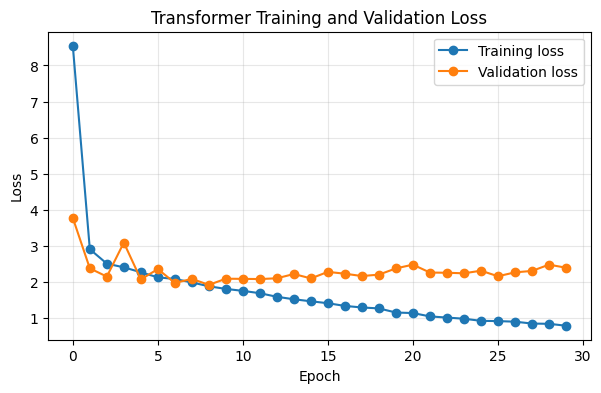

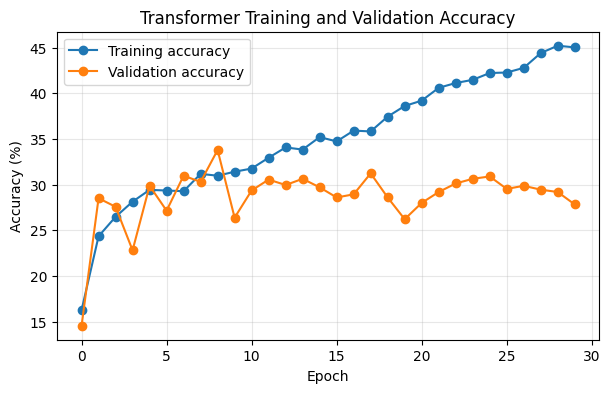

In [ ]:
import matplotlib.pyplot as plt

FIG_DIR.mkdir(parents=True, exist_ok=True)

train_loss = np.atleast_1d(np.loadtxt(PROCESSED_DIR / "transformer_train_loss.csv"))
val_loss = np.atleast_1d(np.loadtxt(PROCESSED_DIR / "transformer_val_loss.csv"))
train_acc = np.atleast_1d(np.loadtxt(PROCESSED_DIR / "transformer_train_acc.csv"))
val_acc = np.atleast_1d(np.loadtxt(PROCESSED_DIR / "transformer_val_acc.csv"))

epochs = np.arange(0, len(train_loss))

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_loss, marker="o", label="Training loss")
plt.plot(epochs, val_loss, marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "transformer_loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_acc * 100, marker="o", label="Training accuracy")
plt.plot(epochs, val_acc * 100, marker="o", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Transformer Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "transformer_accuracy_curve.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
%%run_if TRAIN_MODEL

# Extra qualitative and quantitative analysis of Transformer validation predictions
# This loads the best checkpoint before evaluating.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed()

BATCH_SIZE=16

CHECKPOINT_PATH = PROCESSED_DIR / "checkpoints" / get_model_name(
    batch_size=BATCH_SIZE,
    learning_rate=0.0005,
    epoch=8,
    base_name="hierarchical_transformer"
)


def get_results(CHECKPOINT_PATH, loader):

  print("Loading checkpoint:", CHECKPOINT_PATH)

  try:
    model
  except NameError:
    # Recreate the model on CPU first
    model = HierarchicalTransformer(
        d_model=64,
        nhead=4,
        dropout=0.1,
        dim_feedforward=192
    )

  state_dict = torch.load(
      CHECKPOINT_PATH,
      map_location="cpu",
  )

  model.load_state_dict(state_dict)
  model = model.to(device)
  model.eval()

  all_true = []
  all_pred_raw = []

  with torch.no_grad():
      for batch in loader:
          X = batch["X"].to(device)
          y = batch["y"].to(device)
          note_padding_mask = batch["note_padding_mask"].to(device)
          segment_padding_mask = batch["segment_padding_mask"].to(device)

          outputs = model(X, note_padding_mask, segment_padding_mask)

          all_true.extend(y.cpu().numpy())
          all_pred_raw.extend(outputs.cpu().numpy())

  results = pd.read_csv(PROCESSED_DIR / "test.csv").reset_index(drop=True)

  n = min(len(results), len(all_true))

  results = results.iloc[:n].copy()
  results["true"] = all_true[:n]
  results["pred_raw"] = all_pred_raw[:n]
  results["pred"] = np.clip(np.round(results["pred_raw"]), 0, 11)
  results["error"] = results["pred"] - results["true"]
  results["raw_error"] = results["pred_raw"] - results["true"]

  results["abs_error"] = results["error"].abs()
  results["abs_error_raw"] = results["raw_error"].abs()

  print()
  print("Overall exact accuracy:", (results["pred"] == results["true"]).mean())
  print("Overall within-1 accuracy:", (results["abs_error"] <= 1).mean())
  print("Overall within-2 accuracy:", (results["abs_error"] <= 2).mean())
  print("Mean abs error: ", results["abs_error_raw"].mean())


  accuracy_by_difficulty = (
      results
      .groupby("true")
      .agg(
          count=("true", "count"),
          exact_accuracy=("abs_error", lambda x: (x == 0).mean()),
          within_1_accuracy=("abs_error", lambda x: (x <= 1).mean()),
          mean_abs_error=("abs_error", "mean"),
      )
      .reset_index()
  )

  print()
  print("Accuracy by true difficulty:")
  display(accuracy_by_difficulty)

  # Plot exact accuracy and within-1 accuracy for each difficulty label
  x = np.arange(len(accuracy_by_difficulty))

  plt.figure(figsize=(9, 4.5))
  plt.bar(
      x - 0.2,
      accuracy_by_difficulty["exact_accuracy"],
      0.4,
      label="Exact accuracy",
  )
  plt.bar(
      x + 0.2,
      accuracy_by_difficulty["within_1_accuracy"],
      0.4,
      label="Within-1 accuracy",
  )

  plt.xticks(x, accuracy_by_difficulty["true"].astype(int))
  plt.xlabel("True difficulty")
  plt.ylabel("Accuracy")
  plt.title("Transformer Accuracy by Difficulty")
  plt.ylim(0, 1)
  plt.legend()
  plt.grid(axis="y", alpha=0.3)

  if "FIG_DIR" in globals():
      plt.savefig(FIG_DIR / "transformer_accuracy_by_difficulty.png", dpi=200, bbox_inches="tight")

  plt.show()

  print()
  print("Largest errors:")
  display(
      results
      [["composer", "title", "true", "pred_raw", "pred", "error", "abs_error"]]
      .sort_values("abs_error", ascending=False)
      .head(15)
  )
  return results


Loading checkpoint: /content/drive/MyDrive/APS360_Piano_Difficulty/data/processed/checkpoints/hierarchical_transformer_bs16_lr0.0005_epoch8

Overall exact accuracy: 0.3145299145299145
Overall within-1 accuracy: 0.7760683760683761
Overall within-2 accuracy: 0.941025641025641
Mean abs error:  1.0085166

Accuracy by true difficulty:


,true,count,exact_accuracy,within_1_accuracy,mean_abs_error
0,0.0,25,0.320000,0.720000,1.080000
1,1.0,88,0.431818,0.840909,0.784091
2,2.0,92,0.260870,0.793478,1.054348
3,3.0,103,0.320388,0.699029,1.126214
4,4.0,102,0.294118,0.676471,1.147059
5,5.0,108,0.212963,0.685185,1.129630
6,6.0,128,0.242188,0.781250,1.023438
7,7.0,129,0.310078,0.751938,1.015504
8,8.0,112,0.339286,0.866071,0.821429
9,9.0,110,0.345455,0.836364,0.872727


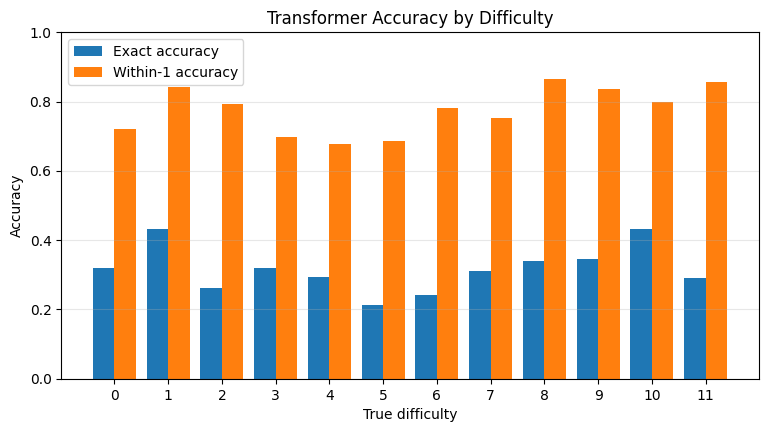


Largest errors:


,composer,title,true,pred_raw,pred,error,abs_error
603,Milne E.,Milne E.Mister Bumble,3.0,9.148502,9.0,6.0,6.0
1031,Watts S.,Watts S.Strange things happen,2.0,6.851809,7.0,5.0,5.0
989,Milne E.,Milne E.Rhyme time,1.0,4.531968,5.0,4.0,4.0
49,Chatman S.,Chatman S.Night Sounds,7.0,3.238337,3.0,-4.0,4.0
67,Chopin F.,Chopin F.Prelude in A minor Op 28 no 2,9.0,4.759815,5.0,-4.0,4.0
113,Stockhausen K.,Stockhausen K.Klavierstucke VII,10.0,6.044705,6.0,-4.0,4.0
231,Hicks-Ward K.,Hicks-Ward K.Boogie blues,1.0,4.695771,5.0,4.0,4.0
317,Kuhlau F.,Kuhlau F.Sonatina - op 59 no 2 F major,6.0,9.885642,10.0,4.0,4.0
133,Chopin F.,Chopin F.Mazurka in C minor Op 30 No 1 CT 68,10.0,6.176266,6.0,-4.0,4.0
137,Stockhausen K.,Stockhausen K.Klavierstucke VIII,10.0,5.979190,6.0,-4.0,4.0


In [ ]:
train_loader, val_loader, test_loader = get_data_loaders(batch_size=BATCH_SIZE, pl_enabled=True)
test_results = get_results(CHECKPOINT_PATH, test_loader)

In [ ]:
# Find more pieces with largest error

display(
    test_results
    [["composer", "title", "true", "pred_raw", "pred", "error", "abs_error"]]
    .sort_values("abs_error", ascending=False)
    .head(50)
)

,composer,title,true,pred_raw,pred,error,abs_error
603,Milne E.,Milne E.Mister Bumble,3.0,9.148502,9.0,6.0,6.0
1031,Watts S.,Watts S.Strange things happen,2.0,6.851809,7.0,5.0,5.0
989,Milne E.,Milne E.Rhyme time,1.0,4.531968,5.0,4.0,4.0
49,Chatman S.,Chatman S.Night Sounds,7.0,3.238337,3.0,-4.0,4.0
67,Chopin F.,Chopin F.Prelude in A minor Op 28 no 2,9.0,4.759815,5.0,-4.0,4.0
113,Stockhausen K.,Stockhausen K.Klavierstucke VII,10.0,6.044705,6.0,-4.0,4.0
231,Hicks-Ward K.,Hicks-Ward K.Boogie blues,1.0,4.695771,5.0,4.0,4.0
317,Kuhlau F.,Kuhlau F.Sonatina - op 59 no 2 F major,6.0,9.885642,10.0,4.0,4.0
133,Chopin F.,Chopin F.Mazurka in C minor Op 30 No 1 CT 68,10.0,6.176266,6.0,-4.0,4.0
137,Stockhausen K.,Stockhausen K.Klavierstucke VIII,10.0,5.979190,6.0,-4.0,4.0


In [ ]:
# Search for a specific piece's results
test_results[
    test_results["title"].str.contains(
        "Melancholy reflections",
        case=False,
        na=False
    )
]

,title,composer,difficulty,YT_chapters,start,end,midi_filename,midi_path,local_midi_path,true,pred_raw,pred,error,raw_error,abs_error,abs_error_raw


In [ ]:
from pathlib import Path
import pandas as pd
import re
import unicodedata

EIGHTNOTES_DIR = PROCESSED_DIR / "8notes"
EIGHTNOTES_MIDI_DIR = EIGHTNOTES_DIR / "midi"

EIGHTNOTES_DIR.mkdir(parents=True, exist_ok=True)
EIGHTNOTES_MIDI_DIR.mkdir(parents=True, exist_ok=True)

EIGHTNOTES_GENRES = [
    "classical",
    "jazz",
    "rock_and_pop",
    "world",
    "film",
    "wedding",
    "christmas",
    "childrens",
    "adults",
    "funeral",
    "christian"
]

EIGHTNOTES_DIFFICULTIES = {
    1: "Beginner",
    2: "Easy",
    3: "Intermediate",
    4: "Advanced",
}

def normalize_name(value):
    # Remove accents, punctuation, and capitalization differences.
    value = unicodedata.normalize("NFKD", str(value))
    value = value.encode("ascii", "ignore").decode("ascii").lower()
    return re.findall(r"[a-z]+(?:-[a-z]+)*", value)

def get_ps_composer(value):
    # e.g. Chopin F. --> Chopin
    tokens = normalize_name(value)
    return tokens[0] if tokens else ""

# Combine main dataset to check for overlaps
ps_metadata = pd.concat(
    [pd.read_csv(PROCESSED_DIR / "train.csv"),
        pd.read_csv(PROCESSED_DIR / "val.csv"),
        pd.read_csv(PROCESSED_DIR / "test.csv"),],
    ignore_index=True,
)

ps_composer_keys = {get_ps_composer(composer) for composer in ps_metadata["composer"].dropna()}


print("Main database pieces:", len(ps_metadata))

# Note that this will be less than the composers in the dataset because
# sometimes multiple composers have the same surname,
# so the script may exclude more than necessary which is okay for this purpose.
print("Composer keys to exclude:", len(ps_composer_keys))

Main database pieces: 7833
Composer keys to exclude: 1136


In [ ]:
import time
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

EIGHTNOTES_BASE_URL = "https://www.8notes.com"
SCORE_URL_PATTERN = re.compile(r"/scores/(\d+)\.asp")

session = requests.Session()

def get_8notes_composer(value):
    # e.g. Beethoven --> beethoven, David Bruce --> bruce
    tokens = normalize_name(value)
    return tokens[-1] if tokens else ""


def scrape_8notes_page(category, difficulty, page):
    url = f"{EIGHTNOTES_BASE_URL}/piano/{category}/sheet_music/"

    response = session.get(
        url,
        params={"difficulty": difficulty, "page": page},
        timeout=30,
    )

    # 8notes returns 404 when the requested page is past the final page.
    if response.status_code == 404:
        return []

    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    rows = []

    for table_row in soup.find_all("tr"):
        score_link = table_row.find("a", href=SCORE_URL_PATTERN)

        if score_link is None:
            continue

        cells = table_row.find_all("td")

        if len(cells) < 4:
            continue

        href = score_link.get("href", "")
        score_match = SCORE_URL_PATTERN.search(href)

        if score_match is None:
            continue

        rows.append({
            "score_id": score_match.group(1),
            "composer": cells[1].get_text(" ", strip=True),
            "title": re.sub(
                r"\s*\(public domain\)\s*$",
                "",
                cells[2].get_text(" ", strip=True),
                flags=re.IGNORECASE,
            ).strip(),
            "category": category,
            "difficulty": difficulty,
            "difficulty_name": EIGHTNOTES_DIFFICULTIES[difficulty],
            "score_url": urljoin(EIGHTNOTES_BASE_URL, href),
            "listing_url": response.url,
        })

    return rows

# Choose the inclusive page range to scrape.
PAGE_START = 101
PAGE_END = 150

EIGHTNOTES_DIR.mkdir(parents=True, exist_ok=True)

metadata_path = EIGHTNOTES_DIR / "8notes_metadata.csv"
candidates_path = EIGHTNOTES_DIR / "8notes_candidates.csv"

# Load previously scraped metadata, if it exists.
if metadata_path.exists():
    old_metadata = pd.read_csv(metadata_path)
    print("Previously saved pieces:", len(old_metadata))
else:
    old_metadata = pd.DataFrame()

new_rows = []

for category in EIGHTNOTES_GENRES:
    for difficulty in EIGHTNOTES_DIFFICULTIES:
        for page in range(PAGE_START, PAGE_END + 1):
            rows = scrape_8notes_page(category, difficulty, page)

            if not rows:
                break

            new_rows.extend(rows)

            print(
                category,
                EIGHTNOTES_DIFFICULTIES[difficulty],
                f"page {page}: {len(rows)} pieces",
            )

            time.sleep(1)

new_metadata = pd.DataFrame(new_rows)

# Add the new results to the old results and keep one row per score.
eightnotes_metadata = (
    pd.concat([old_metadata, new_metadata], ignore_index=True)
    .drop_duplicates("score_id")
    .reset_index(drop=True)
)

eightnotes_metadata["composer_key"] = (eightnotes_metadata["composer"].apply(get_8notes_composer))

# Remove composers already present in PianoSyllabus.
generic_composers = {"trad", "unknown"}

eightnotes_candidates = eightnotes_metadata[
    (
        ~eightnotes_metadata["composer_key"].isin(ps_composer_keys)
        | (
            eightnotes_metadata["composer_key"].isin(generic_composers)
            & eightnotes_metadata["difficulty"].isin([1, 4])
        )
    )
    & (eightnotes_metadata["composer_key"] != "")
].reset_index(drop=True)

eightnotes_metadata.to_csv(metadata_path, index=False)
eightnotes_candidates.to_csv(candidates_path, index=False)

print("\nNew rows scraped:", len(new_metadata))
print("Total unique pieces saved:", len(eightnotes_metadata))
print("Candidates after composer exclusion:", len(eightnotes_candidates))

display(
    eightnotes_candidates
    .groupby(["difficulty", "difficulty_name"])
    .size()
    .rename("pieces")
)

Previously saved pieces: 2946
classical Intermediate page 101: 20 pieces


KeyboardInterrupt: 

In [ ]:
# Manually check pieces with author "trad" to make sure they don't appear in the main dataset
# since too many pieces are marked "trad" to ignore all of them

trad_candidates = eightnotes_candidates[
    eightnotes_candidates["composer_key"].isin(generic_composers)
]

print(f"\nTraditional/unknown candidates: {len(trad_candidates)}")
print(trad_candidates[
        ["difficulty_name", "composer", "title", "category", "score_url"]
    ].to_string(index=False))


Traditional/unknown candidates: 66
difficulty_name composer                                                                       title     category                               score_url
       Beginner    Trad.                                             The First Noel (Beginner Level)    classical https://www.8notes.com/scores/29088.asp
       Beginner    Trad.                                                                This Old Man    classical https://www.8notes.com/scores/38778.asp
   Intermediate  Unknown                                              Spanish Romance (Sor's Melody)    classical https://www.8notes.com/scores/15686.asp
       Beginner    Trad. He's got the Whole World in his Hands (American Spiritual) (Beginner Level) rock_and_pop https://www.8notes.com/scores/29134.asp
       Beginner    Trad.                                Greensleeves (beginners) (Beginners Version)  traditional https://www.8notes.com/scores/12179.asp
       Beginner    Trad.                

In [ ]:
# Remove duplicates and (manually) trad songs that were on PianoSyllabus

eightnotes_candidates["score_id"] = eightnotes_candidates["score_id"].astype(str)

# These are marked with author Trad but are on PianoSyllabus
eightnotes_candidates = eightnotes_candidates[
    ~eightnotes_candidates["score_id"].isin([
        "22783", "28424", "11329", "10381",
        "11349", "38855", "12239",
    ])
].drop_duplicates("score_id").reset_index(drop=True)

eightnotes_candidates.to_csv(EIGHTNOTES_DIR / "8notes_candidates.csv", index=False)

print("Candidates remaining:", len(eightnotes_candidates))

display(
    eightnotes_candidates
    .groupby(["difficulty", "difficulty_name"])
    .size()
    .rename("pieces")
)

Candidates remaining: 733


,,pieces
difficulty,difficulty_name,
1,Beginner,71
2,Easy,118
3,Intermediate,159
4,Advanced,385


In [ ]:
# Balance the classes (scrape more than the end sizes to account for songs
# where midi scraping fails)
sample_sizes = {
    1: 71,   # Beginner
    2: 71,   # Easy
    3: 90,   # Intermediate
    4: 385,   # Advanced
}

eightnotes_test = pd.concat([
    group.sample(n=sample_sizes[difficulty], random_state=42)
    for difficulty, group in eightnotes_candidates.groupby("difficulty")
]).reset_index(drop=True)
display(eightnotes_test)

,score_id,composer,title,category,difficulty,difficulty_name,score_url,listing_url,composer_key
0,28430,Trad.,How Great Thou Art (beginner version),traditional,1,Beginner,https://www.8notes.com/scores/28430.asp,https://www.8notes.com/piano/traditional/sheet...,trad
1,13170,Vivaldi,Spring from the Four Seasons (beginners),classical,1,Beginner,https://www.8notes.com/scores/13170.asp,https://www.8notes.com/piano/classical/sheet_m...,vivaldi
2,38890,Trad.,La Cucaracha (Mexico) (Beginner),world,1,Beginner,https://www.8notes.com/scores/38890.asp,https://www.8notes.com/piano/world/sheet_music...,trad
3,12118,David Bruce,Monkeys,classical,1,Beginner,https://www.8notes.com/scores/12118.asp,https://www.8notes.com/piano/classical/sheet_m...,bruce
4,57602,Trad.,"Rage, Ragetropfli",world,1,Beginner,https://www.8notes.com/scores/57602.asp,https://www.8notes.com/piano/world/sheet_music...,trad
...,...,...,...,...,...,...,...,...,...
612,49272,Strauss II,"Bauern-Polka, Op.276",classical,4,Advanced,https://www.8notes.com/scores/49272.asp,https://www.8notes.com/piano/classical/sheet_m...,ii
613,49550,Strauss II,"Nachtigall-Polka, Op.222",classical,4,Advanced,https://www.8notes.com/scores/49550.asp,https://www.8notes.com/piano/classical/sheet_m...,ii
614,49391,Strauss II,"Feuilleton Walzer, Op.293",classical,4,Advanced,https://www.8notes.com/scores/49391.asp,https://www.8notes.com/piano/classical/sheet_m...,ii
615,49561,Strauss II,"Nimm sie hin!, Op.358",classical,4,Advanced,https://www.8notes.com/scores/49561.asp,https://www.8notes.com/piano/classical/sheet_m...,ii


In [ ]:
MIDI_DIR = EIGHTNOTES_DIR / "midi"


In [ ]:
# Store failed scraps so we don't retry them
FAILED_PATH = EIGHTNOTES_DIR / "8notes_failed_downloads.csv"

if FAILED_PATH.exists():
    failed_downloads = pd.read_csv(FAILED_PATH, dtype={"score_id": str})
else:
    failed_downloads = pd.DataFrame(
        columns=["score_id", "title", "difficulty", "reason"]
    )

failed_ids = set(failed_downloads["score_id"])

def save_failed_download(row, reason):
    global failed_downloads

    failed_downloads = pd.concat([
        failed_downloads,
        pd.DataFrame([{
            "score_id": str(row["score_id"]),
            "title": row["title"],
            "difficulty": row["difficulty"],
            "reason": reason,
        }])
    ]).drop_duplicates("score_id", keep="last")

    failed_downloads.to_csv(FAILED_PATH, index=False)
    failed_ids.add(str(row["score_id"]))

# Download actual midi files
import random
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

MIDI_DIR.mkdir(parents=True, exist_ok=True)

session.headers.update({"User-Agent": "Mozilla/5.0"})
session.mount("https://", HTTPAdapter(max_retries=Retry(
    total=5,
    backoff_factor=10,
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=["GET"],
    respect_retry_after_header=True,
)))

eightnotes_test["score_id"] = eightnotes_test["score_id"].astype(str)
eightnotes_test["midi_path"] = ""

for i, row in eightnotes_test.iterrows():
    path = MIDI_DIR / f"{row['score_id']}.mid"
    score_id = str(row["score_id"])

    if score_id in failed_ids:
        print("Previously failed:", score_id, row["title"])
        continue

    if path.exists() and path.read_bytes()[:4] == b"MThd":
        eightnotes_test.at[i, "midi_path"] = str(path)
        print("Already downloaded:", row["score_id"])
        continue

    try:
        time.sleep(random.uniform(3, 5)) # Sleep to prevent putting load on website
        page = session.get(row["score_url"], timeout=30)
        page.raise_for_status()

        link = BeautifulSoup(page.text, "html.parser").find(
            "a", href=re.compile(r"\.midi?(?:\?|$)", re.IGNORECASE)
        )

        if link is None:
            print("No MIDI:", row["score_id"], row["title"])
            save_failed_download(row, "No MIDI link")
            continue

        time.sleep(random.uniform(3, 5))
        midi = session.get(urljoin(row["score_url"], link["href"]), timeout=60)
        midi.raise_for_status()

        if midi.content[:4] != b"MThd":
            print("Invalid MIDI:", row["score_id"], row["title"])
            save_failed_download(row, "No MIDI link")
            continue

        path.write_bytes(midi.content)
        eightnotes_test.at[i, "midi_path"] = str(path)
        print("Downloaded:", row["score_id"], row["title"])

    except Exception as error:
        save_failed_download(row, "No MIDI link")
        print("Failed:", row["score_id"], error)

eightnotes_test.to_csv(EIGHTNOTES_DIR / "8notes_test.csv", index=False)

print(
    "\nDownloaded:",
    eightnotes_test["midi_path"].ne("").sum(),
    "of",
    len(eightnotes_test),
)

Previously failed: 49716 Wilhelminen-Quadrille, Op.37
Previously failed: 49295 Carnevals-Botschafter Walzer, Op.270
Previously failed: 49687 Vermalungs-Toaste Walzer, Op.136
Previously failed: 49673 Tete-a-Tete-Quadrille, Op.109
Previously failed: 49361 Egyptischer Marsch, Op.335
Previously failed: 49571 Odeon-Quadrille, Op.29
Already downloaded: 58713
Previously failed: 49277 Bitte schon, Op.372
Previously failed: 49618 Saison-Quadrille, Op.283
Previously failed: 49652 Spiralen Walzer, Op.209
Previously failed: 49453 Indra-Quadrille, Op.122
Previously failed: 49460 Italienischer Walzer, Op.407
Previously failed: 49256 Attaque-Quadrille, Op.76
Previously failed: 49671 Telegrafische Depeschen Walzer, Op.195
Previously failed: 49335 Deutsche Walzer, Op.220
Previously failed: 49611 Romanze No.1, Op.243
Previously failed: 49464 Jugend-Traume Walzer, Op.12
Previously failed: 49504 La favorite, Op.217
Previously failed: 49420 Gruss an Wien, Op.225
Previously failed: 49508 Lava-Strome Walzer,

In [ ]:
from tqdm import tqdm
eightnotes_test = pd.read_csv(EIGHTNOTES_DIR / "8notes_test.csv")
eightnotes_test["score_id"] = eightnotes_test["score_id"].astype(str)

valid_rows = []
sequence_rows = []

for _, row in tqdm(eightnotes_test.drop_duplicates("score_id").iterrows(),
                   total=eightnotes_test.shape[0]):

    midi_path = MIDI_DIR / f"{row['score_id']}.mid"

    try:
        segments = midi_to_segments(midi_path)
        features = extract_features(midi_path)

        if not segments:
            raise ValueError("No usable segments")

        valid_rows.append({
            **row.to_dict(),
            **features,
            "midi_path": str(midi_path),
        })

        sequence_rows.append({
            "segments": segments,
            "difficulty": float(row["difficulty"]),
            "composer": row["composer"],
            "title": row["title"],
            "midi_filename": midi_path.name,
        })

    except Exception as error:
        # print("Invalid:", row["score_id"], row["title"], "-", error)
        pass

valid_df = pd.DataFrame(valid_rows)
# Rebalance based on the smallest class to make sure all classes have the same number of pieces
keep = (
    valid_df.groupby("difficulty", group_keys=False)
    .sample(
        n=valid_df.groupby("difficulty").size().min(),
        random_state=42,
    )
    .index
    .sort_values()
)

valid_df = valid_df.loc[keep].reset_index(drop=True)
sequence_rows = [sequence_rows[i] for i in keep]

print("Valid pieces to use:")
display(valid_df)
display(
    valid_df
    .groupby(["difficulty", "difficulty_name"])
    .size()
    .rename("pieces")
)
valid_df.to_csv(EIGHTNOTES_DIR / "8notes_valid.csv", index=False)

torch.save(sequence_rows, SEQUENCE_DIR / "eightnotes_sequences.pt")

print("Saved:", EIGHTNOTES_DIR / "8notes_valid.csv")
print("Saved:", SEQUENCE_DIR / "eightnotes_sequences.pt")

/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Valid pieces to use:


,score_id,composer,title,category,difficulty,difficulty_name,score_url,listing_url,composer_key,midi_path,midi_duration,num_notes,notes_per_second,pitch_range,mean_note_duration,std_note_duration,mean_pitch_jump,max_pitch_jump,mean_tempo
0,28430,Trad.,How Great Thou Art (beginner version),traditional,1,Beginner,https://www.8notes.com/scores/28430.asp,https://www.8notes.com/piano/traditional/sheet...,trad,/content/drive/MyDrive/APS360_Piano_Difficulty...,40.050000,102,2.546816,30,0.647059,0.474333,9.217822,28,100.000000
1,12118,David Bruce,Monkeys,classical,1,Beginner,https://www.8notes.com/scores/12118.asp,https://www.8notes.com/piano/classical/sheet_m...,bruce,/content/drive/MyDrive/APS360_Piano_Difficulty...,9.600000,14,1.458333,5,0.428571,0.314934,2.000000,5,100.000000
2,57602,Trad.,"Rage, Ragetropfli",world,1,Beginner,https://www.8notes.com/scores/57602.asp,https://www.8notes.com/piano/world/sheet_music...,trad,/content/drive/MyDrive/APS360_Piano_Difficulty...,14.433125,60,4.157104,29,0.458135,0.350033,9.949153,22,100.000000
3,606,Trad.,Away in a Manger,traditional,1,Beginner,https://www.8notes.com/scores/606.asp,https://www.8notes.com/piano/traditional/sheet...,trad,/content/drive/MyDrive/APS360_Piano_Difficulty...,23.902344,68,2.844909,16,0.518411,0.292605,4.641791,10,120.000000
4,11327,David Bruce,Cool Blues,jazz,1,Beginner,https://www.8notes.com/scores/11327.asp,https://www.8notes.com/piano/jazz/sheet_music/...,bruce,/content/drive/MyDrive/APS360_Piano_Difficulty...,57.600000,188,3.263889,22,0.591556,0.418933,11.122995,22,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,20490,Strauss II,Tritsch-Tratsch Polka,classical,4,Advanced,https://www.8notes.com/scores/20490.asp,https://www.8notes.com/piano/classical/sheet_m...,ii,/content/drive/MyDrive/APS360_Piano_Difficulty...,210.500000,2609,12.394299,60,0.250178,0.115096,13.218942,54,120.000000
176,38724,Lange,Dein Eigen (Thine Own),classical,4,Advanced,https://www.8notes.com/scores/38724.asp,https://www.8notes.com/piano/classical/sheet_m...,lange,/content/drive/MyDrive/APS360_Piano_Difficulty...,249.417546,1656,6.639469,77,0.478697,0.476347,12.045921,60,72.264502
177,52799,Carcassi,Caprice Op 25 No 4,classical,4,Advanced,https://www.8notes.com/scores/52799.asp,https://www.8notes.com/piano/classical/sheet_m...,carcassi,/content/drive/MyDrive/APS360_Piano_Difficulty...,121.500000,1127,9.275720,48,0.206522,0.193106,12.647425,34,120.000000
178,61057,Trad.,Der Heyser Bulgar (Klezmer),traditional,4,Advanced,https://www.8notes.com/scores/61057.asp,https://www.8notes.com/piano/traditional/sheet...,trad,/content/drive/MyDrive/APS360_Piano_Difficulty...,292.887716,2497,8.525451,39,0.225745,0.190129,10.721955,31,116.000085


,,pieces
difficulty,difficulty_name,
1,Beginner,45
2,Easy,45
3,Intermediate,45
4,Advanced,45


Saved: /content/drive/MyDrive/APS360_Piano_Difficulty/data/processed/8notes/8notes_valid.csv
Saved: /content/drive/MyDrive/APS360_Piano_Difficulty/data/processed/sequence_arrays/eightnotes_sequences.pt


In [ ]:
from scipy.stats import spearmanr, kendalltau
from torch.utils.data import DataLoader

# Load the validated metadata and saved MIDI sequences.
eightnotes_results = pd.read_csv(EIGHTNOTES_DIR / "8notes_valid.csv").reset_index(drop=True)

eightnotes_dataset = PianoSequenceDataset(SEQUENCE_DIR / "eightnotes_sequences.pt")

eightnotes_loader = DataLoader(
    eightnotes_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_piano_batch,
)

# Load the best checkpoint.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HierarchicalTransformer(
    d_model=64,
    nhead=4,
    dropout=0.1,
    dim_feedforward=192
)

CHECKPOINT_PATH = PROCESSED_DIR / "checkpoints" / get_model_name(
    batch_size=16,
    learning_rate=0.0005,
    epoch=8,
)

model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location="cpu"))
model = model.to(device)
model.eval()

transformer_predictions = []

with torch.no_grad():
    for batch in tqdm(eightnotes_loader):
        outputs = model(
            batch["X"].to(device),
            batch["note_padding_mask"].to(device),
            batch["segment_padding_mask"].to(device),
        )

        transformer_predictions.extend(
            outputs.cpu().numpy().reshape(-1)
        )

eightnotes_results["transformer_prediction"] = np.clip(
    transformer_predictions,
    0,
    11,
)

# Compare whether higher 8notes levels receive higher predictions.
def ranking_metrics(labels, predictions):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)

    label_difference = labels[:, None] - labels[None, :]
    prediction_difference = predictions[:, None] - predictions[None, :]
    pairs = np.triu(label_difference != 0, 1)

    pairwise_accuracy = np.where(
        prediction_difference[pairs] == 0,
        0.5,
        np.sign(prediction_difference[pairs])
        == np.sign(label_difference[pairs]),
    ).mean()

    return {
        "Pairwise ordering accuracy": pairwise_accuracy,
        "Spearman correlation": spearmanr(labels, predictions)[0],
        "Kendall tau-b": kendalltau(labels, predictions)[0],
    }


metrics = ranking_metrics(
    eightnotes_results["difficulty"],
    eightnotes_results["transformer_prediction"],
)

print("Pieces by 8notes difficulty:")
display(
    eightnotes_results["difficulty"]
    .value_counts()
    .sort_index()
    .rename("pieces")
)

print("External validation metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.6f}")

print("Predictions by 8notes difficulty:")
display(
    eightnotes_results.groupby(
        ["difficulty", "difficulty_name"]
    ).agg(
        pieces=("score_id", "count"),
        mean_prediction=("transformer_prediction", "mean"),
        median_prediction=("transformer_prediction", "median"),
        prediction_std=("transformer_prediction", "std"),
    )
)

difficulty_names = {
    1: "Beginner",
    2: "Easy",
    3: "Intermediate",
    4: "Advanced",
}

rows = []

for low in range(1, 4):
    for high in range(low + 1, 5):
        row = {
            "Comparison": (
                f"{difficulty_names[low]} vs "
                f"{difficulty_names[high]}"
            )
        }

        low_pred = eightnotes_results.loc[
            eightnotes_results["difficulty"] == low,
            "transformer_prediction",
        ].to_numpy()

        high_pred = eightnotes_results.loc[
            eightnotes_results["difficulty"] == high,
            "transformer_prediction",
        ].to_numpy()

        differences = high_pred[:, None] - low_pred[None, :]

        row["Pairwise accuracy"] = np.mean(
            (differences > 0) + 0.5 * (differences == 0)
        )

        rows.append(row)

pairwise_by_difficulty = pd.DataFrame(rows)
display(pairwise_by_difficulty)


genre_rows = []

for genre, group in eightnotes_results.groupby("category"):
    difficulties = sorted(group["difficulty"].unique())

    row = {
        "Genre": genre,
        "Pieces": len(group),
        "Difficulty levels": len(difficulties),
        "Difficulty counts": (
            group["difficulty"]
            .value_counts()
            .sort_index()
            .to_dict()
        ),
    }

    # Ranking metrics require at least two different difficulty levels.
    if len(difficulties) >= 2:
        genre_metrics = ranking_metrics(
            group["difficulty"],
            group["transformer_prediction"],
        )

        row.update({
            "Pairwise accuracy": (
                genre_metrics["Pairwise ordering accuracy"]
            ),
            "Spearman correlation": (
                genre_metrics["Spearman correlation"]
            ),
            "Kendall tau-b": (
                genre_metrics["Kendall tau-b"]
            ),
        })

    genre_rows.append(row)

genre_metrics = pd.DataFrame(genre_rows).sort_values(
    ["Difficulty levels", "Pieces"],
    ascending=False,
)

display(genre_metrics.round(3))

eightnotes_results.to_csv(
    EIGHTNOTES_DIR / "8notes_results.csv",
    index=False,
)

print("Saved:", EIGHTNOTES_DIR / "8notes_results.csv")

100%|██████████| 12/12 [00:00<00:00, 27.78it/s]

Pieces by 8notes difficulty:


,pieces
difficulty,
1,45
2,45
3,45
4,45


External validation metrics:
Pairwise ordering accuracy: 0.891523
Spearman correlation: 0.823668
Kendall tau-b: 0.680050
Predictions by 8notes difficulty:


,,pieces,mean_prediction,median_prediction,prediction_std
difficulty,difficulty_name,,,,
1,Beginner,45,0.347666,0.287319,0.163644
2,Easy,45,1.373141,0.684804,1.570260
3,Intermediate,45,3.326274,3.201490,2.132870
4,Advanced,45,5.786219,5.386550,1.795907


,Comparison,Pairwise accuracy
0,Beginner vs Easy,0.878025
1,Beginner vs Intermediate,0.958025
2,Beginner vs Advanced,1.000000
3,Easy vs Intermediate,0.760988
4,Easy vs Advanced,0.946173
5,Intermediate vs Advanced,0.805926


,Genre,Pieces,Difficulty levels,Difficulty counts,Pairwise accuracy,Spearman correlation,Kendall tau-b
4,classical,39,4,"{1: 5, 2: 6, 3: 1, 4: 27}",0.978,0.793,0.671
7,rock_and_pop,33,4,"{1: 4, 2: 11, 3: 14, 4: 4}",0.819,0.646,0.534
9,world,26,4,"{1: 12, 2: 1, 3: 6, 4: 7}",0.946,0.882,0.739
6,jazz,21,4,"{1: 1, 2: 5, 3: 9, 4: 6}",0.839,0.712,0.571
8,traditional,21,3,"{1: 18, 2: 2, 4: 1}",0.982,0.587,0.498
1,childrens,5,3,"{1: 3, 2: 1, 3: 1}",0.857,0.671,0.598
5,film,4,3,"{1: 1, 2: 2, 3: 1}",1.000,0.949,0.913
3,christmas,3,3,"{1: 1, 2: 1, 3: 1}",1.000,1.000,1.000
2,christian,25,2,"{2: 13, 3: 12}",0.526,0.044,0.037
0,adults,3,1,{2: 3},NaN,NaN,NaN


Saved: /content/drive/MyDrive/APS360_Piano_Difficulty/data/processed/8notes/8notes_results.csv


In [ ]:
# As a comparison, we can try to find the above metrics for the test set
# to see the difference. Since the number of difficulty levels will impact this,
# for this evaluation I grouped difficulties into 0-2, 3-5, 6-8, and 9-11
# with each group being treated as the same difficulty.
# Note that these will still not be perfectly comparable, but makes for a
# decent measure of how much worse the model got on new data.

# A drop is expected due to the two datasets using different scales

from scipy.stats import spearmanr, kendalltau

_, _, test_loader = get_data_loaders(
    batch_size=16,
    pl_enabled=True,
)

model = HierarchicalTransformer(
    d_model=64,
    nhead=4,
    dropout=0.1,
    dim_feedforward=192,
).to(device)

model.load_state_dict(
    torch.load(CHECKPOINT_PATH, map_location="cpu")
)

model.eval()

test_labels = []
test_predictions = []

with torch.no_grad():
    for batch in test_loader:
        outputs = model(
            batch["X"].to(device),
            batch["note_padding_mask"].to(device),
            batch["segment_padding_mask"].to(device),
        )

        test_labels.extend(batch["y"].numpy())
        test_predictions.extend(outputs.cpu().numpy().reshape(-1))

test_labels = np.asarray(test_labels, dtype=int)
test_predictions = np.asarray(test_predictions)

# Convert 0–11 into four groups: 0–2, 3–5, 6–8, and 9–11.
bucketed_labels = test_labels // 3 + 1

label_difference = bucketed_labels[:, None] - bucketed_labels[None, :]
prediction_difference = test_predictions[:, None] - test_predictions[None, :]
pairs = np.triu(label_difference != 0, 1)

pairwise_accuracy = np.where(
    prediction_difference[pairs] == 0,
    0.5,
    np.sign(prediction_difference[pairs])
    == np.sign(label_difference[pairs]),
).mean()

print("Pieces per difficulty group:")
display(
    pd.Series(bucketed_labels)
    .value_counts()
    .sort_index()
    .rename("pieces")
)

print(f"Pairwise ordering accuracy: {pairwise_accuracy:.6f}")
print(f"Spearman correlation: {spearmanr(bucketed_labels, test_predictions)[0]:.6f}")
print(f"Kendall tau-b: {kendalltau(bucketed_labels, test_predictions)[0]:.6f}")

Pieces per difficulty group:


,pieces
1,205
2,313
3,369
4,283


Pairwise ordering accuracy: 0.935816
Spearman correlation: 0.880076
Kendall tau-b: 0.750006
